In [1]:
import os
import pandas as pd
import numpy as np
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
import matplotlib.ticker as mticker
import matplotlib.pyplot as plt


os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo_State/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_State/"

models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
def format_time_seconds(x, pos=None):
    x = int(round(x))
    minutes = x // 60
    seconds = x % 60
    return f"{minutes}:{seconds:02d}"


In [3]:
os.listdir(models_token_metrics_folder)

['NGramModel',
 'NGramModel_ExtraInfo',
 'NGramModel_ExtraInfo_State',
 'NGramModel_ExtraInfo_segregated',
 'NGramModel_ExtraInfo_TimeDiffTower',
 'NGramModel_ExtraInfo_MultiTowers',
 'RefModels',
 'desktop.ini']

In [4]:
group_variables1 = ["period", "cat_time", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables2 = ["cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables3 = ["period", "cat_time", "cat_dif", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]
group_variables4 = ["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]


### Modelo n-grama referência

In [5]:
df_resultados_modelos_ref = pd.read_parquet(models_token_metrics_folder + "RefModels" + "\\" + "metrics_by_time.parquet")\
.rename(columns = {"cat_time": "t1"})\
.assign(t1 = lambda df: df["t1"] / 10)

In [6]:
df_resultados_modelos_ref_TIME_SIZE = pd.read_parquet(models_token_metrics_folder + "RefModels" + "\\" + "metrics_by_time_TIME_SIZE.parquet")\
.rename(columns = {"cat_time": "t1"})\
.assign(t1 = lambda df: df["t1"] / 10)

In [7]:
df_resultados_modelos_ref

,period,t1,bss,modelo,cross_entropy
0,1,700.0,-0.070659,unigrama,5.021863
1,1,680.0,-0.006308,unigrama,3.803795
2,1,660.0,-0.005560,unigrama,3.807574
3,1,640.0,-0.005730,unigrama,3.814880
4,1,620.0,-0.005471,unigrama,3.819059
...,...,...,...,...,...
427,4,80.0,0.131587,trigrama,3.323652
428,4,60.0,0.139200,trigrama,3.375401
429,4,40.0,0.115647,trigrama,3.626278
430,4,20.0,0.108263,trigrama,3.951836


### Arquitetura A

In [8]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel" + "\\" + "murphy_decomposition_by_season_split.parquet")

In [9]:
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel" + "\\" + "murphy_decomposition_by_dif.parquet")

In [10]:
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel" + "\\" + "murphy_decomposition_by_time.parquet")

In [11]:
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [12]:
os.listdir(models_token_metrics_folder + "NGramModel" + "\\")

['murphy_decomposition_by_time.parquet',
 'murphy_decomposition_by_season_split.parquet',
 'murphy_decomposition_by_time_dif.parquet',
 'murphy_decomposition_by_dif.parquet',
 'desktop.ini']

In [13]:
df_resultados1_arquitetura_a = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_a = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_a = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_a = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [14]:
df_resultados1_arquitetura_a\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       1                   32                 50          3   
1                       1                   32                 50          5   
2                       3                   32                 50          3   
3                       3                   32                 50          5   
4                       5                   32                 50          3   
5                       5                   32                 50          5   

dropout_rate set_covariables                   0.0                        \
layer_norm                                   False                  True   
0                          0  3.0150 (0.0200) [18]  3.0162 (0.0202) [19]   
1                          0  3.0179 (0.0212) [20]  3.0147 (0.0203) [17]   
2                          0   2.9349 (0.0219) [3]   2.9438 (0.0211) [7]   
3                          0   2.9412 (0.0195) [6]   2.9445 (0.0224) [8]   
4                          0   2.9256 (0.0223) [1]   2.9370 (0.0205) [5]   
5                          0   2.9312 (0.0195) [2]   2.9363 (0.0193) [4]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             3.0387 (0.0228) [22]  3.0282 (0.0212) [21]  
1             3.0578 (0.0239) [24]  3.0549 (0.0227) [23]  
2             2.9632 (0.0229) [12]  2.9535 (0.0220) [11]  
3             2.9903 (0.0242) [14]  2.9941 (0.0232) [16]  
4             2.9514 (0.0219) [10]   2.9463 (0.0231) [9]  
5             2.9841 (0.0227) [13]  2.9922 (0.0273) [15]

In [15]:
df_resultados1_arquitetura_a\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "num_layers"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,num_layers,1,3,5
0,0.0,False,3,3.0150 (0.0200) [18],2.9349 (0.0219) [3],2.9256 (0.0223) [1]
1,0.0,False,5,3.0179 (0.0212) [20],2.9412 (0.0195) [6],2.9312 (0.0195) [2]
2,0.0,True,3,3.0162 (0.0202) [19],2.9438 (0.0211) [7],2.9370 (0.0205) [5]
3,0.0,True,5,3.0147 (0.0203) [17],2.9445 (0.0224) [8],2.9363 (0.0193) [4]
4,0.3,False,3,3.0387 (0.0228) [22],2.9632 (0.0229) [12],2.9514 (0.0219) [10]
5,0.3,False,5,3.0578 (0.0239) [24],2.9903 (0.0242) [14],2.9841 (0.0227) [13]
6,0.3,True,3,3.0282 (0.0212) [21],2.9535 (0.0220) [11],2.9463 (0.0231) [9]
7,0.3,True,5,3.0549 (0.0227) [23],2.9941 (0.0232) [16],2.9922 (0.0273) [15]


In [16]:
df_resultados1_arquitetura_a\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "num_layers"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,num_layers,1,3,5
0,0.0,False,3,0.1566 (0.0027) [16],0.1626 (0.0028) [1],0.1626 (0.0029) [2]
1,0.0,False,5,0.1565 (0.0027) [18],0.1621 (0.0028) [4],0.1622 (0.0027) [3]
2,0.0,True,3,0.1566 (0.0027) [17],0.1618 (0.0029) [6],0.1615 (0.0026) [8]
3,0.0,True,5,0.1566 (0.0027) [15],0.1616 (0.0028) [7],0.1618 (0.0026) [5]
4,0.3,False,3,0.1550 (0.0030) [22],0.1599 (0.0029) [12],0.1604 (0.0029) [11]
5,0.3,False,5,0.1529 (0.0032) [24],0.1569 (0.0027) [14],0.1569 (0.0028) [13]
6,0.3,True,3,0.1558 (0.0028) [20],0.1610 (0.0028) [10],0.1612 (0.0029) [9]
7,0.3,True,5,0.1531 (0.0028) [23],0.1558 (0.0033) [19],0.1553 (0.0037) [21]


In [17]:
# df_plot = pd.concat(objs = [
#     df_resultados4_arquitetura_a\
#     .query("period <= 4")\
#     .query("embedding_layer_size == 32 & layer_norm == 1 & dropout_rate == 0 & num_layers == 5 & context_size == 1")\
#     .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)\
#     [["period", "t1", "bss_mean"]]\
#     .sort_values(["period", "t1"], ascending = [True, False])\
#     .rename(columns = {"bss_mean": "bss"})
#     .assign(modelo = "melhor arquitetura A, tamanho contexto 1"),

#     df_resultados_modelos_ref.query("modelo == 'bigrama'")\
#     [["period", "t1", "bss"]]\
#     .sort_values(["period", "t1"], ascending = [True, False])\
#     .assign(modelo = "bigrama")

# ], axis = 0)

# df_resultados4_arquitetura_a\
# .query("period <= 4")\
# .query("embedding_layer_size == 32 & layer_norm == 0 & dropout_rate == 0 & num_layers == 3 & context_size == 3")\
# .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)\
# [["period", "t1", "context_size", "bss_mean"]]\
# .sort_values(["period", "t1"], ascending = [True, False]),

# df_resultados4_arquitetura_a\
# .query("period <= 4")\
# .query("embedding_layer_size == 32 & layer_norm == 1 & dropout_rate == 0 & num_layers == 5 & context_size == 1")\
# .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)\
# [["period", "t1", "context_size", "bss_mean"]]\
# .sort_values(["period", "t1"], ascending = [True, False]),

In [18]:
# fig, ax = plt.subplots(1, 4, figsize = (12, 4))
# for i in range(4):

#     df_plot\
#     .query("period == (@i + 1)")\
#     .pivot_table(index = "t1", columns = "modelo", values = "bss")\
#     .plot(ax = ax[i], legend = False)

# #    bounds_y = [1.5, 8.5]
#     # ax[i].set_ylim(bounds_y)
#     # ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
#     ax[i].invert_xaxis()
#     ax[i].set_xlim(720, -10)
#     ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
#     ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
#     ax[i].tick_params(axis = "x", labelrotation = 90)

#     ax[i].grid(True, alpha = 0.5)
#     ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
#     ax[i].set_xlabel("Tempo restante")

#     if i == 0:
#         ax[i].set_ylabel("Entropia cruzada")
#         ax[i].tick_params(axis = "y", labelleft = True)
#     else:
#         ax[i].set_ylabel("")
#         ax[i].tick_params(axis = "y", left = False, labelleft = False)

# # título geral
# fig.suptitle("Brier Skill Score para o melhor modelo da arquitetura A com tamanho de contexto 1 e bigrama ao longo do tempo restante por período", fontsize = 12, y = 0.92)

# # legenda única embaixo
# handles, labels = ax[0].get_legend_handles_labels()
# fig.legend(handles, labels, title = "Comparação modelos", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.12))

# plt.tight_layout()
# fig.subplots_adjust(wspace = 0.015, top = 0.82, bottom = 0.18)
# plt.show()

In [19]:
df_resultados2_arquitetura_a\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["context_size", "dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size embedding_layer_size num_hidden_neurons num_layers  \
dropout_rate                                                      
layer_norm                                                        
0                              32                 50          3   
1                              32                 50          3   
2                              32                 50          3   
3                              32                 50          3   
4                              32                 50          3   
5                              32                 50          3   
6                              32                 50          3   
7                              32                 50          3   
8                              32                 50          3   
9                              32                 50          5   
10                             32                 50          5   
11                             32                 50          5   
12                             32                 50          5   
13                             32                 50          5   
14                             32                 50          5   
15                             32                 50          5   
16                             32                 50          5   
17                             32                 50          5   

context_size set_covariables cat_dif                     1  \
dropout_rate                                           0.0   
layer_norm                                           False   
0                          0       0  3.0557 (0.0556) [18]   
1                          0       1  3.0422 (0.0317) [18]   
2                          0       2  3.0654 (0.0275) [18]   
3                          0       3  3.0495 (0.0377) [17]   
4                          0       4  2.9483 (0.0226) [17]   
5                          0       5  3.0255 (0.0529) [19]   
6                          0       6  3.0685 (0.0410) [18]   
7                          0       7  3.0386 (0.0332) [18]   
8                          0       8  3.0297 (0.0087) [17]   
9                          0       0  3.0581 (0.0565) [19]   
10                         0       1  3.0460 (0.0320) [20]   
11                         0       2  3.0671 (0.0273) [20]   
12                         0       3  3.0531 (0.0411) [20]   
13                         0       4  2.9506 (0.0237) [20]   
14                         0       5  3.0284 (0.0552) [20]   
15                         0       6  3.0728 (0.0434) [20]   
16                         0       7  3.0416 (0.0329) [20]   
17                         0       8  3.0329 (0.0115) [20]   

context_size                                              \
dropout_rate                                         0.3   
layer_norm                    True                 False   
0             3.0593 (0.0511) [20]  3.0768 (0.0575) [22]   
1             3.0427 (0.0310) [19]  3.0669 (0.0358) [22]   
2             3.0666 (0.0274) [19]  3.0891 (0.0311) [22]   
3             3.0499 (0.0389) [18]  3.0724 (0.0375) [22]   
4             2.9498 (0.0232) [19]  2.9676 (0.0242) [22]   
5             3.0247 (0.0557) [18]  3.0494 (0.0533) [22]   
6             3.0707 (0.0437) [19]  3.0959 (0.0434) [22]   
7             3.0394 (0.0326) [19]  3.0667 (0.0354) [22]   
8             3.0316 (0.0079) [19]  3.0618 (0.0104) [22]   
9             3.0541 (0.0535) [17]  3.0949 (0.0572) [24]   
10            3.0422 (0.0291) [17]  3.0842 (0.0354) [24]   
11            3.0651 (0.0278) [17]  3.1079 (0.0302) [24]   
12            3.0500 (0.0406) [19]  3.0919 (0.0380) [24]   
13            2.9484 (0.0233) [18]  2.9866 (0.0261) [24]   
14            3.0238 (0.0538) [17]  3.0679 (0.0551) [24]   
15            3.0683 (0.0416) [17]  3.1164 (0.0461) [24]   
16            3.0375 (0.0325) [17]  3.0880 (0.0363) [24]   
17            3.0301 (0.0099) [18]  3.0766 (0.0117) [24]   

context_size                

In [20]:
df_resultados3_arquitetura_a\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,embedding_layer_size,num_hidden_neurons,num_layers,set_covariables,1,3,5
0,0.0,False,32,50,3,0,3.2714 (0.1059) [15],3.0191 (0.1013) [5],2.9201 (0.0836) [2]
1,0.0,False,32,50,5,0,3.2829 (0.1007) [16],3.0838 (0.1267) [9],2.9219 (0.1237) [3]
2,0.0,True,32,50,3,0,3.2614 (0.0946) [13],3.0335 (0.1157) [7],2.9100 (0.1184) [1]
3,0.0,True,32,50,5,0,3.2686 (0.1026) [14],3.0293 (0.0840) [6],2.9607 (0.1173) [4]
4,0.3,False,32,50,3,0,3.3836 (0.0811) [22],3.2496 (0.0961) [12],3.0873 (0.0937) [10]
5,0.3,False,32,50,5,0,3.4377 (0.0624) [23],3.3332 (0.0858) [20],3.2839 (0.0722) [17]
6,0.3,True,32,50,3,0,3.3497 (0.0933) [21],3.1646 (0.1151) [11],3.0718 (0.1120) [8]
7,0.3,True,32,50,5,0,3.4392 (0.0714) [24],3.3312 (0.0738) [19],3.3099 (0.0493) [18]


In [21]:
df_resultados4_arquitetura_a\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,embedding_layer_size,num_hidden_neurons,num_layers,set_covariables,1,3,5
0,0.0,False,32,50,3,0,3.9036 (0.1510) [18],3.6276 (0.1323) [5],3.5517 (0.2120) [3]
1,0.0,False,32,50,5,0,3.8950 (0.1577) [15],3.7092 (0.1759) [10],3.5204 (0.1650) [1]
2,0.0,True,32,50,3,0,3.8986 (0.1284) [17],3.6717 (0.1670) [7],3.5407 (0.1618) [2]
3,0.0,True,32,50,5,0,3.8952 (0.1711) [16],3.6682 (0.1634) [6],3.5915 (0.2170) [4]
4,0.3,False,32,50,3,0,3.9599 (0.1258) [21],3.8156 (0.1393) [12],3.6846 (0.1347) [8]
5,0.3,False,32,50,5,0,4.0039 (0.1307) [23],3.8827 (0.1627) [14],3.8484 (0.1581) [13]
6,0.3,True,32,50,3,0,3.9718 (0.1515) [22],3.7834 (0.1571) [11],3.7074 (0.1765) [9]
7,0.3,True,32,50,5,0,4.0211 (0.1462) [24],3.9072 (0.1433) [19],3.9113 (0.1453) [20]


In [22]:
df_resultados4_arquitetura_a\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,embedding_layer_size,num_hidden_neurons,num_layers,set_covariables,1,3,5
0,0.0,False,32,50,3,0,2.5068 (0.7508) [2],2.6622 (0.7042) [24],2.5381 (0.6879) [8]
1,0.0,False,32,50,5,0,2.5245 (0.7339) [6],2.5427 (0.7366) [9],2.5155 (0.6223) [5]
2,0.0,True,32,50,3,0,2.5109 (0.7436) [4],2.5690 (0.7451) [15],2.5527 (0.6409) [10]
3,0.0,True,32,50,5,0,2.5561 (0.7613) [11],2.6214 (0.7033) [23],2.5727 (0.6452) [16]
4,0.3,False,32,50,3,0,2.5584 (0.7709) [12],2.5765 (0.7242) [18],2.5090 (0.6910) [3]
5,0.3,False,32,50,5,0,2.6116 (0.8043) [21],2.6153 (0.7677) [22],2.5671 (0.7530) [14]
6,0.3,True,32,50,3,0,2.5736 (0.7713) [17],2.5370 (0.7215) [7],2.4821 (0.6146) [1]
7,0.3,True,32,50,5,0,2.5966 (0.7844) [20],2.5647 (0.7322) [13],2.5815 (0.7170) [19]


In [23]:
df_resultados4_arquitetura_a\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["dropout_rate", "layer_norm", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["context_size"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

context_size,dropout_rate,layer_norm,embedding_layer_size,num_hidden_neurons,num_layers,set_covariables,1,3,5
0,0.0,False,32,50,3,0,2.2157 (0.4480) [13],2.1610 (0.3946) [4],2.1021 (0.3860) [1]
1,0.0,False,32,50,5,0,2.1847 (0.4401) [8],2.1391 (0.3354) [3],2.1653 (0.4262) [5]
2,0.0,True,32,50,3,0,2.1894 (0.4619) [9],2.1919 (0.3916) [10],2.1031 (0.3963) [2]
3,0.0,True,32,50,5,0,2.1958 (0.4101) [11],2.1802 (0.3891) [7],2.2192 (0.4248) [14]
4,0.3,False,32,50,3,0,2.3779 (0.4979) [20],2.3155 (0.4230) [19],2.2428 (0.4129) [15]
5,0.3,False,32,50,5,0,2.4142 (0.4949) [24],2.3793 (0.4641) [21],2.4001 (0.5286) [22]
6,0.3,True,32,50,3,0,2.2689 (0.4705) [16],2.1993 (0.4677) [12],2.1774 (0.4617) [6]
7,0.3,True,32,50,5,0,2.4029 (0.5378) [23],2.3001 (0.5542) [17],2.3150 (0.4727) [18]


### Arquitetura B

In [24]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_season_split.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_dif.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_time.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [25]:
df_resultados1_arquitetura_b = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_b = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_b = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_b = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [26]:
df_resultados1_arquitetura_b\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.7812 (0.0178) [2]  2.7905 (0.0204) [7]   
1                          2  2.7780 (0.0203) [1]  2.7861 (0.0205) [4]   
2                          1  2.7917 (0.0171) [8]  2.7903 (0.0200) [6]   
3                          2  2.7837 (0.0182) [3]  2.7863 (0.0210) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8211 (0.0179) [12]  2.8083 (0.0201) [10]  
1             2.8162 (0.0206) [11]   2.8042 (0.0199) [9]  
2             2.8588 (0.0218) [15]  2.8618 (0.0214) [16]  
3             2.8549 (0.0203) [13]  2.8553 (0.0172) [14]

In [27]:
df_resultados1_arquitetura_b\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.assign(metrica = lambda df: df["metrica"].str.replace("^0\.", ".", regex = True))\
.assign(metrica = lambda df: df["metrica"].str.replace("\(0\.", "(.", regex = True))\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                0.0                     \
layer_norm                                False               True   
0                          1  .1726 (.0025) [3]  .1716 (.0026) [8]   
1                          2  .1730 (.0028) [1]  .1723 (.0025) [4]   
2                          1  .1720 (.0024) [5]  .1718 (.0025) [7]   
3                          2  .1726 (.0027) [2]  .1720 (.0028) [6]   

dropout_rate                 0.3                      
layer_norm                 False                True  
0             .1690 (.0029) [12]  .1702 (.0030) [10]  
1             .1693 (.0030) [11]   .1707 (.0031) [9]  
2             .1643 (.0030) [14]  .1638 (.0032) [16]  
3             .1645 (.0020) [13]  .1643 (.0026) [15]

In [28]:
df_resultados2_arquitetura_b\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
3                       5                   32                 50          3   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
8                       5                   32                 50          3   
9                       5                   32                 50          3   
10                      5                   32                 50          3   
11                      5                   32                 50          3   
12                      5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
17                      5                   32                 50          3   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
22                      5                   32                 50          5   
23                      5                   32                 50          5   
24                      5                   32                 50          5   
25                      5                   32                 50          5   
26                      5                   32                 50          5   
27                      5                   32                 50          5   
28                      5                   32                 50          5   
29                      5                   32                 50          5   
30                      5                   32                 50          5   
31                      5                   32                 50          5   
32                      5                   32                 50          5   
33                      5                   32                 50          5   
34                      5                   32                 50          5   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                          1       0  2.8368 (0.0622) [3]   
1                          1       1  2.8003 (0.0262) [2]   
2                          1       2  2.8173 (0.0143) [2]   
3                          1       3  2.8044 (0.0360) [2]   
4                          1       4  2.7276 (0.0196) [3]   
5                          1       5  2.7885 (0.0448) [2]   
6                          1       6  2.8235 (0.0381) [2]   
7                          1       7  2.8020 (0.0306) [2]   
8                          1       8  2.7995 (0.0270) [4]   
9                          2       0  2.8341 (0.0598) [1]   
10                         2       1  2.7963 (0.0302) [1]   
11                         2       2  2.8133 (0.0162) [1]   
12                         2       3  2.7999 (0.0375) [1]   
13                         2       4  2.7232

In [29]:
df_resultados3_arquitetura_b\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.0274 (0.1354) [5]  2.0584 (0.0927) [6]   
1                          2  1.9540 (0.0875) [1]  1.9714 (0.1029) [2]   
2                          1  2.0902 (0.1363) [9]  2.0647 (0.1251) [8]   
3                          2  1.9743 (0.1334) [3]  1.9970 (0.1020) [4]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.2195 (0.1175) [13]  2.1811 (0.1063) [11]  
1             2.1292 (0.1176) [10]   2.0604 (0.1068) [7]  
2             2.3096 (0.1243) [16]  2.2894 (0.1164) [15]  
3             2.2287 (0.1290) [14]  2.2038 (0.1190) [12]

In [30]:
df_resultados4_arquitetura_b\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.6389 (0.1924) [5]  2.6865 (0.1406) [7]   
1                          2  2.5391 (0.1223) [1]  2.5674 (0.1417) [3]   
2                          1  2.7274 (0.1385) [9]  2.6863 (0.1704) [6]   
3                          2  2.5518 (0.1435) [2]  2.6206 (0.1198) [4]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8630 (0.1258) [12]  2.8482 (0.1398) [11]  
1             2.7781 (0.1173) [10]   2.7072 (0.1145) [8]  
2             2.9997 (0.1591) [16]  2.9853 (0.1661) [15]  
3             2.8992 (0.1453) [13]  2.9146 (0.1365) [14]

In [31]:
df_resultados4_arquitetura_b\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.0465 (0.4959) [6]  1.1138 (0.4859) [10]   
1                          2  0.9989 (0.4845) [4]   0.9441 (0.4626) [1]   
2                          1  1.0871 (0.4869) [8]  1.1357 (0.4888) [12]   
3                          2  1.0358 (0.5237) [5]   0.9584 (0.4433) [2]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.2521 (0.4075) [15]  1.2157 (0.3821) [13]  
1             1.1260 (0.4977) [11]   0.9899 (0.4902) [3]  
2             1.3112 (0.4299) [16]  1.2372 (0.4139) [14]  
3              1.1134 (0.4774) [9]   1.0824 (0.4613) [7]

In [32]:
df_resultados4_arquitetura_b\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                   0.0                       \
layer_norm                                   False                 True   
0                          1   0.9080 (0.3281) [8]  0.8951 (0.3448) [7]   
1                          2   0.8451 (0.3431) [4]  0.8044 (0.3200) [3]   
2                          1  0.9552 (0.3470) [11]  0.9262 (0.3424) [9]   
3                          2   0.7931 (0.2742) [2]  0.7765 (0.2228) [1]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.0745 (0.3047) [15]  0.9990 (0.2895) [13]  
1             0.9282 (0.3103) [10]   0.8646 (0.2944) [5]  
2             1.0890 (0.3606) [16]  1.0428 (0.2944) [14]  
3             0.9576 (0.3364) [12]   0.8879 (0.3099) [6]

### Arquitetura B Spent Time

In [33]:
df_murphy_decomposition_by_season_split_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")
df_murphy_decomposition_by_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_dif_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_time_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo" + "\\" + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet")

In [34]:
df_resultados1_arquitetura_b_TIME = df_murphy_decomposition_by_season_split_TIME\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_b_TIME = df_murphy_decomposition_by_diff_TIME\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_b_TIME = df_murphy_decomposition_by_time_TIME\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_b_TIME = df_murphy_decomposition_by_time_diff_TIME\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [35]:
df_resultados1_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.3751 (0.0215) [2]  2.3833 (0.0221) [8]   
1                          2  2.3752 (0.0216) [3]  2.3798 (0.0222) [5]   
2                          1  2.3778 (0.0234) [4]  2.3805 (0.0225) [7]   
3                          2  2.3740 (0.0215) [1]  2.3799 (0.0201) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3879 (0.0233) [12]  2.3864 (0.0229) [11]  
1              2.3842 (0.0201) [9]  2.3843 (0.0242) [10]  
2             2.4006 (0.0226) [15]  2.4011 (0.0224) [16]  
3             2.4000 (0.0204) [14]  2.3952 (0.0219) [13]

In [36]:
df_resultados1_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  0.1622 (0.0041) [3]  0.1609 (0.0043) [8]   
1                          2  0.1620 (0.0043) [4]  0.1611 (0.0044) [7]   
2                          1  0.1623 (0.0044) [2]  0.1613 (0.0044) [6]   
3                          2  0.1628 (0.0042) [1]  0.1613 (0.0040) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1599 (0.0043) [12]  0.1606 (0.0043) [10]  
1             0.1603 (0.0037) [11]   0.1609 (0.0045) [9]  
2             0.1583 (0.0041) [15]  0.1586 (0.0044) [14]  
3             0.1580 (0.0037) [16]  0.1592 (0.0043) [13]

In [37]:
df_resultados1_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()


dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  24.500 (0.3488) [5]  24.557 (0.3539) [9]   
1                          2  24.465 (0.3726) [2]  24.538 (0.3285) [7]   
2                          1  24.550 (0.3907) [8]  24.496 (0.3575) [4]   
3                          2  24.455 (0.3401) [1]  24.489 (0.3133) [3]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.817 (0.3686) [14]  24.584 (0.3426) [10]  
1             24.688 (0.3571) [12]   24.500 (0.3506) [6]  
2             24.926 (0.3719) [16]  24.747 (0.3446) [13]  
3             24.845 (0.3237) [15]  24.660 (0.3443) [11]

In [38]:
df_resultados2_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
3                       5                   32                 50          3   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
8                       5                   32                 50          3   
9                       5                   32                 50          3   
10                      5                   32                 50          3   
11                      5                   32                 50          3   
12                      5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
17                      5                   32                 50          3   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
22                      5                   32                 50          5   
23                      5                   32                 50          5   
24                      5                   32                 50          5   
25                      5                   32                 50          5   
26                      5                   32                 50          5   
27                      5                   32                 50          5   
28                      5                   32                 50          5   
29                      5                   32                 50          5   
30                      5                   32                 50          5   
31                      5                   32                 50          5   
32                      5                   32                 50          5   
33                      5                   32                 50          5   
34                      5                   32                 50          5   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                          1       0  2.4187 (0.0399) [4]   
1                          1       1  2.3891 (0.0325) [1]   
2                          1       2  2.3855 (0.0244) [2]   
3                          1       3  2.4027 (0.0340) [3]   
4                          1       4  2.3461 (0.0215) [1]   
5                          1       5  2.3596 (0.0365) [3]   
6                          1       6  2.3867 (0.0309) [3]   
7                          1       7  2.3915 (0.0449) [2]   
8                          1       8  2.3988 (0.0156) [3]   
9                          2       0  2.4145 (0.0397) [2]   
10                         2       1  2.3912 (0.0326) [2]   
11                         2       2  2.3851 (0.0240) [1]   
12                         2       3  2.4010 (0.0320) [2]   
13                         2       4  2.3474

In [39]:
df_resultados3_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.7667 (0.0628) [4]  1.8467 (0.0656) [10]   
1                          2  1.7626 (0.0647) [3]  1.8572 (0.0614) [12]   
2                          1  1.7203 (0.0672) [2]   1.8387 (0.0809) [9]   
3                          2  1.7008 (0.0772) [1]  1.8559 (0.0759) [11]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.8081 (0.0547) [8]  1.8797 (0.0682) [14]  
1             1.7794 (0.0566) [5]  1.8583 (0.0563) [13]  
2             1.8039 (0.0783) [7]  1.9264 (0.0624) [16]  
3             1.7924 (0.1065) [6]  1.8867 (0.0705) [15]

In [40]:
df_resultados4_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.8614 (0.0491) [2]  1.8998 (0.0637) [11]   
1                          2  1.8898 (0.0470) [7]   1.8846 (0.0624) [5]   
2                          1  1.8792 (0.0486) [4]   1.8867 (0.0767) [6]   
3                          2  1.8508 (0.0700) [1]  1.9127 (0.0762) [14]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0              1.8967 (0.0500) [8]  1.9130 (0.0725) [15]  
1              1.8718 (0.0527) [3]  1.8985 (0.0638) [10]  
2             1.9059 (0.0703) [13]  1.9391 (0.0766) [16]  
3              1.8977 (0.0817) [9]  1.9047 (0.0951) [12]

In [41]:
df_resultados4_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.5053 (0.5353) [8]  1.6135 (0.5247) [10]   
1                          2  1.4710 (0.5545) [4]  1.6495 (0.5273) [12]   
2                          1  1.3561 (0.5976) [2]   1.6025 (0.5722) [9]   
3                          2  1.3461 (0.5834) [1]  1.6306 (0.6181) [11]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.5007 (0.6379) [7]  1.6620 (0.5943) [14]  
1             1.4758 (0.5705) [5]  1.6513 (0.5878) [13]  
2             1.4776 (0.6527) [6]  1.7716 (0.5903) [16]  
3             1.4639 (0.5084) [3]  1.6919 (0.6342) [15]

In [42]:
df_resultados4_arquitetura_b_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.3882 (0.4170) [4]  1.5802 (0.3804) [11]   
1                          2  1.3585 (0.4343) [3]  1.6590 (0.4801) [15]   
2                          1  1.2463 (0.4206) [2]  1.5852 (0.4192) [12]   
3                          2  1.2241 (0.4258) [1]   1.5484 (0.4274) [9]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.4323 (0.3953) [7]  1.6228 (0.4389) [14]  
1             1.4032 (0.3979) [5]  1.5777 (0.4457) [10]  
2             1.4670 (0.4768) [8]  1.7080 (0.4630) [16]  
3             1.4072 (0.4258) [6]  1.6111 (0.4289) [13]

### Arquitetura B (fine-tuning)

In [43]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_season_split.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_dif.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_time.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [44]:
df_resultados1_arquitetura_b_fn = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_b_fn = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_b_fn = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_b_fn = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [45]:
df_resultados1_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.7810 (0.0183) [2]  2.7935 (0.0210) [7]   
1                          2  2.7769 (0.0200) [1]  2.7906 (0.0216) [5]   
2                          1  2.7899 (0.0188) [4]  2.7950 (0.0199) [8]   
3                          2  2.7848 (0.0183) [3]  2.7906 (0.0199) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8148 (0.0187) [12]  2.8022 (0.0188) [10]  
1             2.8101 (0.0207) [11]   2.7991 (0.0214) [9]  
2             2.8458 (0.0208) [15]  2.8495 (0.0205) [16]  
3             2.8401 (0.0202) [13]  2.8411 (0.0186) [14]

In [46]:
df_resultados1_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.assign(metrica = lambda df: df["metrica"].str.replace("^0\.", ".", regex = True))\
.assign(metrica = lambda df: df["metrica"].str.replace("\(0\.", "(.", regex = True))\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                0.0                     \
layer_norm                                False               True   
0                          1  .1725 (.0025) [2]  .1714 (.0027) [7]   
1                          2  .1730 (.0028) [1]  .1717 (.0026) [5]   
2                          1  .1720 (.0027) [4]  .1714 (.0026) [8]   
3                          2  .1724 (.0027) [3]  .1716 (.0026) [6]   

dropout_rate                 0.3                      
layer_norm                 False                True  
0             .1695 (.0028) [12]  .1707 (.0028) [10]  
1             .1699 (.0030) [11]   .1711 (.0030) [9]  
2             .1658 (.0031) [14]  .1648 (.0031) [16]  
3             .1664 (.0025) [13]  .1655 (.0027) [15]

In [47]:
df_resultados2_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
3                       5                   32                 50          3   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
8                       5                   32                 50          3   
9                       5                   32                 50          3   
10                      5                   32                 50          3   
11                      5                   32                 50          3   
12                      5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
17                      5                   32                 50          3   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
22                      5                   32                 50          5   
23                      5                   32                 50          5   
24                      5                   32                 50          5   
25                      5                   32                 50          5   
26                      5                   32                 50          5   
27                      5                   32                 50          5   
28                      5                   32                 50          5   
29                      5                   32                 50          5   
30                      5                   32                 50          5   
31                      5                   32                 50          5   
32                      5                   32                 50          5   
33                      5                   32                 50          5   
34                      5                   32                 50          5   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                   0.0  \
layer_norm                                           False   
0                          1       0   2.8397 (0.0638) [2]   
1                          1       1   2.7993 (0.0278) [2]   
2                          1       2   2.8166 (0.0148) [2]   
3                          1       3   2.8036 (0.0360) [2]   
4                          1       4   2.7275 (0.0201) [2]   
5                          1       5   2.7882 (0.0449) [2]   
6                          1       6   2.8239 (0.0382) [2]   
7                          1       7   2.8024 (0.0314) [2]   
8                          1       8   2.7984 (0.0264) [2]   
9                          2       0   2.8383 (0.0593) [1]   
10                         2       1   2.7944 (0.0304) [1]   
11                         2       2   2.8119 (0.0145) [1]   
12                         2       3   2.7984 (0.0373) [1]   
13                         2 

In [48]:
df_resultados3_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.0129 (0.1385) [5]  2.0693 (0.0958) [9]   
1                          2  1.9507 (0.0950) [1]  1.9808 (0.1185) [2]   
2                          1  2.0625 (0.1294) [8]  2.0562 (0.1027) [7]   
3                          2  1.9888 (0.1370) [3]  2.0062 (0.1215) [4]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.2067 (0.1194) [13]  2.1577 (0.1011) [11]  
1             2.1085 (0.1188) [10]   2.0417 (0.1079) [6]  
2             2.2854 (0.1244) [16]  2.2634 (0.1157) [15]  
3             2.2068 (0.1249) [14]  2.1801 (0.1196) [12]

In [49]:
df_resultados4_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.6266 (0.1955) [4]  2.7134 (0.1460) [9]   
1                          2  2.5390 (0.1359) [1]  2.5721 (0.1565) [3]   
2                          1  2.6839 (0.1399) [7]  2.6927 (0.1626) [8]   
3                          2  2.5702 (0.1549) [2]  2.6558 (0.1479) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8500 (0.1360) [12]  2.8184 (0.1448) [11]  
1             2.7510 (0.1171) [10]   2.6784 (0.1176) [6]  
2             2.9795 (0.1652) [16]  2.9484 (0.1611) [15]  
3             2.8911 (0.1358) [14]  2.8828 (0.1212) [13]

In [50]:
df_resultados4_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.0309 (0.4950) [5]  1.1371 (0.4332) [12]   
1                          2  0.9818 (0.4787) [3]   0.9371 (0.4750) [1]   
2                          1  1.0952 (0.5039) [9]   1.0916 (0.5439) [8]   
3                          2  1.0606 (0.5209) [6]   0.9685 (0.4254) [2]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.2210 (0.4134) [14]  1.1845 (0.3891) [13]  
1             1.1225 (0.4892) [11]   0.9820 (0.5008) [4]  
2             1.2924 (0.4306) [16]  1.2430 (0.4236) [15]  
3             1.1088 (0.4783) [10]   1.0647 (0.4893) [7]

In [51]:
df_resultados4_arquitetura_b_fn\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                   0.0                       \
layer_norm                                   False                 True   
0                          1   0.8794 (0.3238) [8]  0.8550 (0.3048) [5]   
1                          2   0.8457 (0.3360) [4]  0.8233 (0.3600) [3]   
2                          1  0.9378 (0.3054) [12]  0.8690 (0.2548) [6]   
3                          2   0.8058 (0.3059) [2]  0.7937 (0.2013) [1]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.0585 (0.3081) [15]  0.9826 (0.2904) [13]  
1             0.9139 (0.3036) [10]   0.8775 (0.3198) [7]  
2             1.0701 (0.3371) [16]  1.0513 (0.3155) [14]  
3             0.9251 (0.3274) [11]   0.8937 (0.3215) [9]

### Arquitetura B (fine-tuning) Spent Time

In [52]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_dif_TIME_MODEL.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_time_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_segregated" + "\\" + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet")

In [53]:
df_resultados1_arquitetura_b_fn_TIME = df_murphy_decomposition_by_season_split_TIME\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_b_fn_TIME = df_murphy_decomposition_by_diff_TIME\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_b_fn_TIME = df_murphy_decomposition_by_time_TIME\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_b_fn_TIME = df_murphy_decomposition_by_time_diff_TIME\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [54]:
df_resultados1_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.3751 (0.0215) [2]  2.3833 (0.0221) [8]   
1                          2  2.3752 (0.0216) [3]  2.3798 (0.0222) [5]   
2                          1  2.3778 (0.0234) [4]  2.3805 (0.0225) [7]   
3                          2  2.3740 (0.0215) [1]  2.3799 (0.0201) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3879 (0.0233) [12]  2.3864 (0.0229) [11]  
1              2.3842 (0.0201) [9]  2.3843 (0.0242) [10]  
2             2.4006 (0.0226) [15]  2.4011 (0.0224) [16]  
3             2.4000 (0.0204) [14]  2.3952 (0.0219) [13]

In [55]:
df_resultados1_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  0.1622 (0.0041) [3]  0.1609 (0.0043) [8]   
1                          2  0.1620 (0.0043) [4]  0.1611 (0.0044) [7]   
2                          1  0.1623 (0.0044) [2]  0.1613 (0.0044) [6]   
3                          2  0.1628 (0.0042) [1]  0.1613 (0.0040) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1599 (0.0043) [12]  0.1606 (0.0043) [10]  
1             0.1603 (0.0037) [11]   0.1609 (0.0045) [9]  
2             0.1583 (0.0041) [15]  0.1586 (0.0044) [14]  
3             0.1580 (0.0037) [16]  0.1592 (0.0043) [13]

In [56]:
df_resultados1_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()


dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  24.500 (0.3488) [5]  24.557 (0.3539) [9]   
1                          2  24.465 (0.3726) [2]  24.538 (0.3285) [7]   
2                          1  24.550 (0.3907) [8]  24.496 (0.3575) [4]   
3                          2  24.455 (0.3401) [1]  24.489 (0.3133) [3]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.817 (0.3686) [14]  24.584 (0.3426) [10]  
1             24.688 (0.3571) [12]   24.500 (0.3506) [6]  
2             24.926 (0.3719) [16]  24.747 (0.3446) [13]  
3             24.845 (0.3237) [15]  24.660 (0.3443) [11]

In [57]:
df_resultados2_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
3                       5                   32                 50          3   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
8                       5                   32                 50          3   
9                       5                   32                 50          3   
10                      5                   32                 50          3   
11                      5                   32                 50          3   
12                      5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
17                      5                   32                 50          3   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
22                      5                   32                 50          5   
23                      5                   32                 50          5   
24                      5                   32                 50          5   
25                      5                   32                 50          5   
26                      5                   32                 50          5   
27                      5                   32                 50          5   
28                      5                   32                 50          5   
29                      5                   32                 50          5   
30                      5                   32                 50          5   
31                      5                   32                 50          5   
32                      5                   32                 50          5   
33                      5                   32                 50          5   
34                      5                   32                 50          5   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                          1       0  2.4187 (0.0399) [4]   
1                          1       1  2.3891 (0.0325) [1]   
2                          1       2  2.3855 (0.0244) [2]   
3                          1       3  2.4027 (0.0340) [3]   
4                          1       4  2.3461 (0.0215) [1]   
5                          1       5  2.3596 (0.0365) [3]   
6                          1       6  2.3867 (0.0309) [3]   
7                          1       7  2.3915 (0.0449) [2]   
8                          1       8  2.3988 (0.0156) [3]   
9                          2       0  2.4145 (0.0397) [2]   
10                         2       1  2.3912 (0.0326) [2]   
11                         2       2  2.3851 (0.0240) [1]   
12                         2       3  2.4010 (0.0320) [2]   
13                         2       4  2.3474

In [58]:
df_resultados3_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.7667 (0.0628) [4]  1.8467 (0.0656) [10]   
1                          2  1.7626 (0.0647) [3]  1.8572 (0.0614) [12]   
2                          1  1.7203 (0.0672) [2]   1.8387 (0.0809) [9]   
3                          2  1.7008 (0.0772) [1]  1.8559 (0.0759) [11]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.8081 (0.0547) [8]  1.8797 (0.0682) [14]  
1             1.7794 (0.0566) [5]  1.8583 (0.0563) [13]  
2             1.8039 (0.0783) [7]  1.9264 (0.0624) [16]  
3             1.7924 (0.1065) [6]  1.8867 (0.0705) [15]

In [59]:
df_resultados4_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.8614 (0.0491) [2]  1.8998 (0.0637) [11]   
1                          2  1.8898 (0.0470) [7]   1.8846 (0.0624) [5]   
2                          1  1.8792 (0.0486) [4]   1.8867 (0.0767) [6]   
3                          2  1.8508 (0.0700) [1]  1.9127 (0.0762) [14]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0              1.8967 (0.0500) [8]  1.9130 (0.0725) [15]  
1              1.8718 (0.0527) [3]  1.8985 (0.0638) [10]  
2             1.9059 (0.0703) [13]  1.9391 (0.0766) [16]  
3              1.8977 (0.0817) [9]  1.9047 (0.0951) [12]

In [60]:
df_resultados4_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.5053 (0.5353) [8]  1.6135 (0.5247) [10]   
1                          2  1.4710 (0.5545) [4]  1.6495 (0.5273) [12]   
2                          1  1.3561 (0.5976) [2]   1.6025 (0.5722) [9]   
3                          2  1.3461 (0.5834) [1]  1.6306 (0.6181) [11]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.5007 (0.6379) [7]  1.6620 (0.5943) [14]  
1             1.4758 (0.5705) [5]  1.6513 (0.5878) [13]  
2             1.4776 (0.6527) [6]  1.7716 (0.5903) [16]  
3             1.4639 (0.5084) [3]  1.6919 (0.6342) [15]

In [61]:
df_resultados4_arquitetura_b_fn_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.3882 (0.4170) [4]  1.5802 (0.3804) [11]   
1                          2  1.3585 (0.4343) [3]  1.6590 (0.4801) [15]   
2                          1  1.2463 (0.4206) [2]  1.5852 (0.4192) [12]   
3                          2  1.2241 (0.4258) [1]   1.5484 (0.4274) [9]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.4323 (0.3953) [7]  1.6228 (0.4389) [14]  
1             1.4032 (0.3979) [5]  1.5777 (0.4457) [10]  
2             1.4670 (0.4768) [8]  1.7080 (0.4630) [16]  
3             1.4072 (0.4258) [6]  1.6111 (0.4289) [13]

### Arquitetura C

In [62]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_season_split.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_dif.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_time.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [63]:
df_resultados1_arquitetura_c = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_c = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_c = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_c = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [64]:
df_resultados1_arquitetura_c\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.7780 (0.0190) [2]  2.7855 (0.0195) [3]   
1                          2  2.7765 (0.0202) [1]  2.7875 (0.0198) [6]   
2                          1  2.7885 (0.0192) [8]  2.7876 (0.0193) [7]   
3                          2  2.7863 (0.0201) [4]  2.7870 (0.0192) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.8162 (0.0216) [12]  2.8033 (0.0211) [10]  
1             2.8144 (0.0201) [11]   2.8026 (0.0212) [9]  
2             2.8484 (0.0178) [13]  2.8528 (0.0211) [15]  
3             2.8484 (0.0235) [14]  2.8532 (0.0213) [16]

In [65]:
df_resultados1_arquitetura_c\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.assign(metrica = lambda df: df["metrica"].str.replace("^0\.", ".", regex = True))\
.assign(metrica = lambda df: df["metrica"].str.replace("\(0\.", "(.", regex = True))\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                0.0                     \
layer_norm                                False               True   
0                          1  .1729 (.0027) [2]  .1724 (.0027) [4]   
1                          2  .1729 (.0026) [1]  .1721 (.0027) [8]   
2                          1  .1721 (.0026) [7]  .1723 (.0026) [6]   
3                          2  .1725 (.0026) [3]  .1723 (.0026) [5]   

dropout_rate                 0.3                      
layer_norm                 False                True  
0             .1696 (.0032) [11]   .1709 (.0028) [9]  
1             .1695 (.0029) [12]  .1709 (.0033) [10]  
2             .1652 (.0027) [14]  .1648 (.0030) [15]  
3             .1654 (.0033) [13]  .1646 (.0029) [16]

In [66]:
df_resultados2_arquitetura_c\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          3   
27                      5                   32                 50          5   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
28                      5                   32                 50          5   
10                      5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          3   
29                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
30                      5                   32                 50          5   
12                      5                   32                 50          3   
3                       5                   32                 50          3   
31                      5                   32                 50          5   
22                      5                   32                 50          5   
4                       5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
5                       5                   32                 50          3   
23                      5                   32                 50          5   
32                      5                   32                 50          5   
6                       5                   32                 50          3   
24                      5                   32                 50          5   
33                      5                   32                 50          5   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
34                      5                   32                 50          5   
25                      5                   32                 50          5   
7                       5                   32                 50          3   
26                      5                   32                 50          5   
17                      5                   32                 50          3   
8                       5                   32                 50          3   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                          1       0  2.8249 (0.0593) [1]   
9                          2       0  2.8291 (0.0585) [2]   
27                         2       0  2.8421 (0.0705) [5]   
18                         1       0  2.8457 (0.0636) [8]   
19                         1       1  2.8035 (0.0263) [5]   
28                         2       1  2.8028 (0.0289) [4]   
10                         2       1  2.7952 (0.0292) [2]   
1                          1       1  2.7950 (0.0286) [1]   
2                          1       2  2.8116 (0.0150) [2]   
11                         2       2  2.8115 (0.0156) [1]   
29                         2       2  2.8212 (0.0140) [4]   
20                         1       2  2.8256 (0.0125) [8]   
21                         1       3  2.8131 (0.0412) [8]   
30                         2       3  2.8079

In [67]:
df_resultados3_arquitetura_c\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  1.9292 (0.1160) [1]  1.9651 (0.1018) [4]   
1                          2  1.9343 (0.1007) [2]  1.9707 (0.1165) [5]   
2                          1  1.9876 (0.0876) [8]  1.9772 (0.0966) [7]   
3                          2  1.9649 (0.0997) [3]  1.9744 (0.1031) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.0757 (0.1145) [12]  2.0214 (0.0819) [10]  
1             2.0711 (0.1137) [11]   1.9962 (0.1009) [9]  
2             2.1763 (0.1399) [15]  2.1789 (0.1173) [16]  
3             2.1620 (0.1116) [14]  2.1611 (0.1040) [13]

In [68]:
df_resultados4_arquitetura_c\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.5475 (0.1159) [2]  2.6046 (0.1434) [7]   
1                          2  2.5421 (0.1418) [1]  2.5969 (0.1165) [5]   
2                          1  2.6024 (0.1759) [6]  2.6106 (0.1190) [8]   
3                          2  2.5839 (0.1366) [4]  2.5813 (0.1491) [3]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.7120 (0.0933) [12]  2.6583 (0.1258) [10]  
1             2.7093 (0.1165) [11]   2.6254 (0.1113) [9]  
2             2.8587 (0.1527) [14]  2.8917 (0.1113) [16]  
3             2.8411 (0.1293) [13]  2.8687 (0.1271) [15]

In [69]:
df_resultados4_arquitetura_c\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                   0.0                       \
layer_norm                                   False                 True   
0                          1   0.9796 (0.4324) [6]  0.9608 (0.4701) [4]   
1                          2  0.9967 (0.5308) [10]  0.9786 (0.4684) [5]   
2                          1   0.9967 (0.4558) [9]  0.9853 (0.4204) [7]   
3                          2   0.9583 (0.4532) [2]  0.9884 (0.4378) [8]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.0203 (0.4745) [11]   0.9389 (0.5005) [1]  
1             1.0238 (0.4578) [12]   0.9598 (0.5059) [3]  
2             1.0633 (0.5731) [16]  1.0364 (0.4840) [13]  
3             1.0623 (0.4985) [15]  1.0609 (0.5533) [14]

In [70]:
df_resultados4_arquitetura_c\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                   0.0                       \
layer_norm                                   False                 True   
0                          1  0.8379 (0.2961) [13]  0.8218 (0.3039) [7]   
1                          2   0.8321 (0.2854) [9]  0.7945 (0.2805) [4]   
2                          1   0.8181 (0.2581) [6]  0.7926 (0.2579) [3]   
3                          2   0.7826 (0.2586) [2]  0.8094 (0.3093) [5]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.8360 (0.2773) [12]   0.8224 (0.3035) [8]  
1             0.8353 (0.2982) [11]   0.7787 (0.3071) [1]  
2             0.8388 (0.2938) [14]  0.8340 (0.3356) [10]  
3             0.8659 (0.3450) [16]  0.8576 (0.3527) [15]

### Arquitetura C Spent Time

In [71]:
df_murphy_decomposition_by_season_split_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")
df_murphy_decomposition_by_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_dif_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_time_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_State" + "\\" + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet")

In [72]:
df_resultados1_arquitetura_c_TIME = df_murphy_decomposition_by_season_split_TIME\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_c_TIME = df_murphy_decomposition_by_diff_TIME\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_c_TIME = df_murphy_decomposition_by_time_TIME\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_c_TIME = df_murphy_decomposition_by_time_diff_TIME\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [73]:
df_resultados1_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  2.3709 (0.0219) [3]  2.3773 (0.0231) [8]   
1                          2  2.3698 (0.0222) [1]  2.3756 (0.0219) [5]   
2                          1  2.3710 (0.0200) [4]  2.3764 (0.0220) [7]   
3                          2  2.3704 (0.0214) [2]  2.3759 (0.0213) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             2.3801 (0.0213) [11]  2.3802 (0.0228) [12]  
1             2.3775 (0.0212) [10]   2.3773 (0.0224) [9]  
2             2.3940 (0.0194) [16]  2.3929 (0.0211) [14]  
3             2.3929 (0.0211) [15]  2.3906 (0.0232) [13]

In [74]:
df_resultados1_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  0.1621 (0.0044) [4]  0.1610 (0.0047) [9]   
1                          2  0.1622 (0.0046) [3]  0.1611 (0.0043) [5]   
2                          1  0.1626 (0.0040) [2]  0.1611 (0.0045) [8]   
3                          2  0.1627 (0.0043) [1]  0.1611 (0.0042) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             0.1605 (0.0041) [12]  0.1607 (0.0044) [11]  
1             0.1608 (0.0040) [10]   0.1611 (0.0042) [7]  
2             0.1583 (0.0036) [15]  0.1592 (0.0040) [14]  
3             0.1582 (0.0041) [16]  0.1594 (0.0044) [13]

In [75]:
df_resultados1_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()


dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  24.348 (0.3430) [7]   24.387 (0.3031) [9]   
1                          2  24.306 (0.3841) [3]   24.318 (0.3124) [5]   
2                          1  24.316 (0.3189) [4]  24.426 (0.4407) [11]   
3                          2  24.285 (0.3380) [1]   24.338 (0.3206) [6]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             24.530 (0.3391) [14]   24.353 (0.3259) [8]  
1             24.459 (0.3545) [12]   24.296 (0.3453) [2]  
2             24.613 (0.3215) [15]  24.517 (0.3268) [13]  
3             24.615 (0.3648) [16]  24.419 (0.3707) [10]

In [76]:
df_resultados2_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          3   
27                      5                   32                 50          5   
18                      5                   32                 50          5   
19                      5                   32                 50          5   
28                      5                   32                 50          5   
10                      5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          3   
29                      5                   32                 50          5   
20                      5                   32                 50          5   
21                      5                   32                 50          5   
30                      5                   32                 50          5   
12                      5                   32                 50          3   
3                       5                   32                 50          3   
31                      5                   32                 50          5   
22                      5                   32                 50          5   
4                       5                   32                 50          3   
13                      5                   32                 50          3   
14                      5                   32                 50          3   
5                       5                   32                 50          3   
23                      5                   32                 50          5   
32                      5                   32                 50          5   
6                       5                   32                 50          3   
24                      5                   32                 50          5   
33                      5                   32                 50          5   
15                      5                   32                 50          3   
16                      5                   32                 50          3   
34                      5                   32                 50          5   
25                      5                   32                 50          5   
7                       5                   32                 50          3   
26                      5                   32                 50          5   
17                      5                   32                 50          3   
8                       5                   32                 50          3   
35                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                          1       0  2.4162 (0.0369) [4]   
9                          2       0  2.4147 (0.0401) [3]   
27                         2       0  2.4114 (0.0393) [1]   
18                         1       0  2.4119 (0.0394) [2]   
19                         1       1  2.3837 (0.0285) [1]   
28                         2       1  2.3858 (0.0293) [2]   
10                         2       1  2.3862 (0.0330) [3]   
1                          1       1  2.3868 (0.0322) [4]   
2                          1       2  2.3810 (0.0221) [2]   
11                         2       2  2.3815 (0.0246) [3]   
29                         2       2  2.3767 (0.0256) [1]   
20                         1       2  2.3828 (0.0250) [4]   
21                         1       3  2.3939 (0.0312) [3]   
30                         2       3  2.3945

In [77]:
df_resultados3_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.7508 (0.0646) [4]  1.8338 (0.0611) [11]   
1                          2  1.7451 (0.0781) [3]  1.8392 (0.0600) [12]   
2                          1  1.7002 (0.0707) [1]  1.8327 (0.0707) [10]   
3                          2  1.7012 (0.0811) [2]   1.8181 (0.0568) [9]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.7634 (0.0502) [8]  1.8407 (0.0564) [14]  
1             1.7617 (0.0646) [7]  1.8392 (0.0501) [13]  
2             1.7559 (0.0620) [5]  1.8835 (0.0516) [16]  
3             1.7596 (0.0585) [6]  1.8747 (0.0703) [15]

In [78]:
df_resultados4_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                          1  1.8664 (0.0459) [9]  1.8536 (0.0697) [3]   
1                          2  1.8651 (0.0627) [8]  1.8649 (0.0489) [7]   
2                          1  1.8540 (0.0366) [4]  1.8649 (0.0669) [6]   
3                          2  1.8436 (0.0662) [1]  1.8496 (0.0676) [2]   

dropout_rate                   0.3                        
layer_norm                   False                  True  
0             1.8713 (0.0649) [12]  1.8691 (0.0735) [11]  
1              1.8621 (0.0606) [5]  1.8682 (0.0754) [10]  
2             1.8851 (0.0768) [14]  1.9105 (0.0994) [16]  
3             1.8761 (0.0789) [13]  1.9097 (0.0943) [15]

In [79]:
df_resultados4_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.5058 (0.6036) [8]   1.5645 (0.6235) [9]   
1                          2  1.4686 (0.5949) [6]  1.6444 (0.5677) [13]   
2                          1  1.3644 (0.6203) [1]  1.6266 (0.6252) [10]   
3                          2  1.3826 (0.6289) [2]  1.6430 (0.5661) [12]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.4616 (0.6148) [5]  1.6730 (0.6342) [14]  
1             1.4803 (0.6138) [7]  1.6368 (0.5797) [11]  
2             1.4406 (0.6254) [4]  1.6875 (0.5958) [15]  
3             1.3965 (0.6064) [3]  1.6911 (0.5972) [16]

In [80]:
df_resultados4_arquitetura_c_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          3   
2                       5                   32                 50          5   
3                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                        \
layer_norm                                  False                  True   
0                          1  1.3725 (0.4319) [6]  1.6317 (0.4489) [14]   
1                          2  1.3452 (0.4238) [4]  1.6332 (0.4738) [15]   
2                          1  1.2333 (0.4082) [2]  1.6740 (0.4685) [16]   
3                          2  1.2329 (0.4341) [1]  1.6177 (0.4225) [12]   

dropout_rate                  0.3                        
layer_norm                  False                  True  
0             1.3803 (0.4338) [7]  1.6261 (0.4276) [13]  
1             1.3811 (0.4147) [8]  1.6090 (0.4006) [10]  
2             1.3350 (0.3942) [3]  1.6123 (0.4165) [11]  
3             1.3646 (0.4203) [5]   1.5958 (0.4503) [9]

### Arquitetura D

In [81]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_season_split.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_dif.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_time.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [82]:
df_resultados1_arquitetura_d = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_d = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_d = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_d = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [83]:
df_resultados1_arquitetura_d\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.7763 (0.0196) [1]  2.7864 (0.0201) [3]   
1                         56  2.7828 (0.0212) [2]  2.7868 (0.0202) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.8190 (0.0220) [6]  2.8102 (0.0212) [5]  
1             2.8542 (0.0175) [7]  2.8670 (0.0253) [8]

In [84]:
df_resultados1_arquitetura_d\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.assign(metrica = lambda df: df["metrica"].str.replace("^0\.", ".", regex = True))\
.assign(metrica = lambda df: df["metrica"].str.replace("\(0\.", "(.", regex = True))\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                0.0                     \
layer_norm                                False               True   
0                         56  .1731 (.0026) [1]  .1723 (.0025) [3]   
1                         56  .1727 (.0028) [2]  .1723 (.0028) [4]   

dropout_rate                0.3                     
layer_norm                False               True  
0             .1689 (.0030) [6]  .1703 (.0032) [5]  
1             .1647 (.0031) [7]  .1632 (.0033) [8]

In [85]:
df_resultados2_arquitetura_d\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          5   
10                      5                   32                 50          5   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          5   
12                      5                   32                 50          5   
3                       5                   32                 50          3   
13                      5                   32                 50          5   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
14                      5                   32                 50          5   
15                      5                   32                 50          5   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
16                      5                   32                 50          5   
8                       5                   32                 50          3   
17                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                         56       0  2.8262 (0.0603) [1]   
9                         56       0  2.8364 (0.0669) [3]   
10                        56       1  2.7999 (0.0251) [2]   
1                         56       1  2.7958 (0.0268) [1]   
2                         56       2  2.8145 (0.0151) [1]   
11                        56       2  2.8202 (0.0142) [2]   
12                        56       3  2.8106 (0.0389) [3]   
3                         56       3  2.7990 (0.0384) [1]   
13                        56       4  2.7266 (0.0247) [2]   
4                         56       4  2.7225 (0.0214) [1]   
5                         56       5  2.7837 (0.0464) [1]   
14                        56       5  2.7906 (0.0496) [2]   
15                        56       6  2.8263 (0.0411) [2]   
6                         56       6  2.8172 (0.0425) [1]   
7                         56       7  2.7988 (0.0314) [1]   
16                        56       7  2.8058 (0.0335) [2]   
8                         56       8  2.7951 (0.0218) [1]   
17                        56       8  2.8021 (0.0251) [3]   

dropout_rate                                       0.3                       
layer_norm                   True                False                 True  
0             2.8354 (0.0602) [2]  2.8621 (0.0642) [6]  2.8532 (0.0635) [5]  
9             2.8447 (0.0655) [4]  2.8899 (0.0561) [7]  2.9033 (0.0699) [8]  
10            2.8077 (0.0251) [4]  2.8695 (0.0351) [7]  2.8824 (0.0343) [8]  
1             2.8060 (0.0306) [3]  2.8324 (0.0322) [6]  2.8223 (0.0341) [5]  
2             2.8239 (0.0147) [3]  2.8589 (0.0185) [6]  2.8490 (0.0221) [5]  
11            2.8254 (0.0172) [4]  2.8913 (0.0234) [7]  2.9054 (0.0228) [8]  
12            2.8101 (0.0326) [2]  2.8874 (0.0406) [7]  2.9018 (0.0483) [8]  
3             2.8144 (0.0335) [4]  2.8474 (0.0398) [6]  2.8424 (0.0381) [5]  
13            2.7317 (0.0235) [4]  2.7979 (0.0234) [7]  2.8086 (0.0247) [8]  
4             2.7306 (0.0232) [3]  2.7627 (0.0241) [6]  2.7541 (0.0222) [5]  
5             2.7961 (0.0506) [4]  2.8315 (0.0490) [6]  2.8224 (0.0517) [5]  
14            2.7934 (0.0479) [3]  2.8690 (0.0438) [7]  2.8819 (0.0562) [8]  
15            2.8302 (0.0399) [3]  2.9007 (0.0348) [7]  2.9168 (0.0478) [8]  
6       

In [86]:
df_resultados3_arquitetura_d\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.9307 (0.1230) [1]  1.9899 (0.1001) [2]   
1                         56  1.9967 (0.0881) [3]  2.0045 (0.0982) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.2241 (0.0982) [6]  2.1820 (0.1060) [5]  
1             2.2978 (0.1352) [7]  2.3245 (0.1152) [8]

In [87]:
df_resultados4_arquitetura_d\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.4817 (0.1361) [1]  2.6163 (0.1363) [3]   
1                         56  2.6026 (0.1179) [2]  2.6300 (0.1024) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.8757 (0.1138) [6]  2.8734 (0.1303) [5]  
1             2.9986 (0.1298) [7]  3.0650 (0.1741) [8]

In [88]:
df_resultados4_arquitetura_d\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 3")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.2698 (0.2742) [1]  2.3081 (0.2200) [2]   
1                         56  2.3112 (0.2294) [3]  2.3510 (0.2514) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.5735 (0.2024) [6]  2.5266 (0.2315) [5]  
1             2.7189 (0.2293) [7]  2.7372 (0.1488) [8]

In [89]:
df_resultados4_arquitetura_d\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.8359 (0.3201) [4]  0.8190 (0.2941) [3]   
1                         56  0.7752 (0.2944) [2]  0.7676 (0.2584) [1]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.0703 (0.3080) [8]  1.0177 (0.3227) [6]  
1             1.0600 (0.3015) [7]  0.9940 (0.3005) [5]

### Arquitetura D Spent Time

In [90]:
df_murphy_decomposition_by_season_split_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")
df_murphy_decomposition_by_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_dif_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_time_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_TimeDiffTower" + "\\" + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet")

In [91]:
df_resultados1_arquitetura_d_TIME = df_murphy_decomposition_by_season_split_TIME\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_d_TIME = df_murphy_decomposition_by_diff_TIME\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_d_TIME = df_murphy_decomposition_by_time_TIME\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_d_TIME = df_murphy_decomposition_by_time_diff_TIME\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [92]:
df_resultados1_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.3647 (0.0220) [2]  2.3783 (0.0237) [3]   
1                         56  2.3647 (0.0231) [1]  2.3789 (0.0221) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.3863 (0.0208) [6]  2.3862 (0.0229) [5]  
1             2.4002 (0.0208) [8]  2.4001 (0.0218) [7]

In [93]:
df_resultados1_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.1626 (0.0044) [2]  0.1613 (0.0046) [4]   
1                         56  0.1630 (0.0044) [1]  0.1615 (0.0043) [3]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             0.1602 (0.0040) [6]  0.1607 (0.0042) [5]  
1             0.1583 (0.0040) [8]  0.1588 (0.0042) [7]

In [94]:
df_resultados1_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()


dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  24.141 (0.3565) [2]  24.416 (0.3558) [3]   
1                         56  24.130 (0.3693) [1]  24.484 (0.3722) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             24.770 (0.3739) [7]  24.599 (0.3739) [5]  
1             24.917 (0.3427) [8]  24.741 (0.3382) [6]

In [95]:
df_resultados2_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          5   
10                      5                   32                 50          5   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          5   
12                      5                   32                 50          5   
3                       5                   32                 50          3   
13                      5                   32                 50          5   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
14                      5                   32                 50          5   
15                      5                   32                 50          5   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
16                      5                   32                 50          5   
8                       5                   32                 50          3   
17                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                         56       0  2.4091 (0.0436) [1]   
9                         56       0  2.4093 (0.0415) [2]   
10                        56       1  2.3806 (0.0302) [2]   
1                         56       1  2.3776 (0.0309) [1]   
2                         56       2  2.3746 (0.0203) [2]   
11                        56       2  2.3710 (0.0260) [1]   
12                        56       3  2.3875 (0.0335) [1]   
3                         56       3  2.3903 (0.0316) [2]   
13                        56       4  2.3392 (0.0245) [2]   
4                         56       4  2.3374 (0.0233) [1]   
5                         56       5  2.3504 (0.0362) [2]   
14                        56       5  2.3491 (0.0371) [1]   
15                        56       6  2.3726 (0.0316) [1]   
6                         56       6  2.3734 (0.0298) [2]   
7                         56       7  2.3806 (0.0435) [1]   
16                        56       7  2.3829 (0.0423) [2]   
8                         56       8  2.3896 (0.0174) [2]   
17                        56       8  2.3825 (0.0189) [1]   

dropout_rate                                       0.3                       
layer_norm                   True                False                 True  
0             2.4240 (0.0476) [3]  2.4251 (0.0413) [4]  2.4311 (0.0430) [6]  
9             2.4272 (0.0459) [5]  2.4347 (0.0383) [7]  2.4454 (0.0447) [8]  
10            2.3969 (0.0345) [4]  2.4179 (0.0314) [8]  2.4167 (0.0366) [7]  
1             2.3953 (0.0377) [3]  2.4027 (0.0314) [5]  2.4041 (0.0353) [6]  
2             2.3899 (0.0213) [4]  2.3965 (0.0244) [6]  2.3952 (0.0238) [5]  
11            2.3872 (0.0201) [3]  2.4112 (0.0216) [8]  2.4107 (0.0247) [7]  
12            2.4073 (0.0323) [4]  2.4243 (0.0302) [8]  2.4235 (0.0357) [7]  
3             2.4017 (0.0337) [3]  2.4115 (0.0321) [6]  2.4111 (0.0343) [5]  
13            2.3480 (0.0225) [3]  2.3709 (0.0216) [8]  2.3694 (0.0230) [7]  
4             2.3494 (0.0227) [4]  2.3574 (0.0215) [6]  2.3557 (0.0241) [5]  
5             2.3636 (0.0362) [3]  2.3701 (0.0337) [6]  2.3692 (0.0353) [5]  
14            2.3652 (0.0375) [4]  2.3838 (0.0320) [8]  2.3814 (0.0336) [7]  
15            2.3900 (0.0299) [4]  2.4151 (0.0312) [7]  2.4186 (0.0356) [8]  
6       

In [96]:
df_resultados3_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.7375 (0.0624) [2]  1.8382 (0.0490) [5]   
1                         56  1.6835 (0.0705) [1]  1.8465 (0.0670) [6]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.8049 (0.0651) [4]  1.8831 (0.0560) [7]  
1             1.7898 (0.0750) [3]  1.9152 (0.0426) [8]

In [97]:
df_resultados4_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.8501 (0.0687) [2]  1.8900 (0.0812) [4]   
1                         56  1.8424 (0.0577) [1]  1.8936 (0.0619) [5]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.8864 (0.0640) [3]  1.9092 (0.0632) [6]  
1             1.9100 (0.0692) [7]  1.9300 (0.0704) [8]

In [98]:
df_resultados4_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.4591 (0.5519) [3]  1.6303 (0.5594) [5]   
1                         56  1.3359 (0.5709) [1]  1.7623 (0.6443) [8]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.5234 (0.5668) [4]  1.6748 (0.5505) [6]  
1             1.4100 (0.6419) [2]  1.7350 (0.5917) [7]

In [99]:
df_resultados4_arquitetura_d_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.3569 (0.4589) [3]  1.5998 (0.4525) [5]   
1                         56  1.2272 (0.4306) [1]  1.6138 (0.4480) [6]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.4490 (0.4136) [4]  1.6317 (0.4020) [7]  
1             1.3496 (0.4295) [2]  1.6729 (0.4570) [8]

### Arquitetura E

In [100]:
df_murphy_decomposition_by_season_split = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_season_split.parquet")
df_murphy_decomposition_by_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_dif.parquet")
df_murphy_decomposition_by_time = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_time.parquet")
df_murphy_decomposition_by_time_diff = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_time_dif.parquet")

In [101]:
df_resultados1_arquitetura_e = df_murphy_decomposition_by_season_split\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_e = df_murphy_decomposition_by_diff\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_e = df_murphy_decomposition_by_time\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_e = df_murphy_decomposition_by_time_diff\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [102]:
df_resultados1_arquitetura_e\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.7790 (0.0211) [3]  2.7764 (0.0205) [1]   
1                         56  2.7938 (0.0217) [4]  2.7783 (0.0201) [2]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.8680 (0.0173) [6]  2.8656 (0.0171) [5]  
1             2.9044 (0.0241) [7]  2.9392 (0.0334) [8]

In [103]:
df_resultados1_arquitetura_e\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.assign(metrica = lambda df: df["metrica"].str.replace("^0\.", ".", regex = True))\
.assign(metrica = lambda df: df["metrica"].str.replace("\(0\.", "(.", regex = True))\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", 'set_covariables'], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                0.0                     \
layer_norm                                False               True   
0                         56  .1729 (.0028) [2]  .1732 (.0026) [1]   
1                         56  .1719 (.0024) [4]  .1728 (.0026) [3]   

dropout_rate                0.3                     
layer_norm                False               True  
0             .1627 (.0029) [6]  .1629 (.0030) [5]  
1             .1595 (.0032) [7]  .1581 (.0025) [8]

In [104]:
df_resultados2_arquitetura_e\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          5   
10                      5                   32                 50          5   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          5   
12                      5                   32                 50          5   
3                       5                   32                 50          3   
13                      5                   32                 50          5   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
14                      5                   32                 50          5   
15                      5                   32                 50          5   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
16                      5                   32                 50          5   
8                       5                   32                 50          3   
17                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                         56       0  2.8348 (0.0673) [2]   
9                         56       0  2.8535 (0.0676) [4]   
10                        56       1  2.8109 (0.0239) [4]   
1                         56       1  2.7982 (0.0274) [2]   
2                         56       2  2.8149 (0.0177) [2]   
11                        56       2  2.8293 (0.0137) [4]   
12                        56       3  2.8205 (0.0453) [4]   
3                         56       3  2.8003 (0.0389) [3]   
13                        56       4  2.7364 (0.0219) [4]   
4                         56       4  2.7228 (0.0241) [2]   
5                         56       5  2.7872 (0.0453) [3]   
14                        56       5  2.8031 (0.0505) [4]   
15                        56       6  2.8380 (0.0449) [4]   
6                         56       6  2.8254 (0.0382) [3]   
7                         56       7  2.8040 (0.0344) [3]   
16                        56       7  2.8171 (0.0364) [4]   
8                         56       8  2.7962 (0.0254) [3]   
17                        56       8  2.8146 (0.0230) [4]   

dropout_rate                                       0.3                       
layer_norm                   True                False                 True  
0             2.8343 (0.0653) [1]  2.9075 (0.0577) [5]  2.9107 (0.0541) [6]  
9             2.8404 (0.0652) [3]  2.9373 (0.0563) [7]  2.9692 (0.0620) [8]  
10            2.7984 (0.0251) [3]  2.9228 (0.0409) [7]  2.9613 (0.0395) [8]  
1             2.7960 (0.0305) [1]  2.8859 (0.0356) [6]  2.8853 (0.0352) [5]  
2             2.8135 (0.0118) [1]  2.9091 (0.0234) [6]  2.9070 (0.0221) [5]  
11            2.8155 (0.0157) [3]  2.9446 (0.0287) [7]  2.9803 (0.0210) [8]  
12            2.7998 (0.0376) [2]  2.9358 (0.0394) [7]  2.9708 (0.0564) [8]  
3             2.7949 (0.0384) [1]  2.8988 (0.0429) [6]  2.8969 (0.0406) [5]  
13            2.7236 (0.0221) [3]  2.8446 (0.0299) [7]  2.8748 (0.0247) [8]  
4             2.7217 (0.0226) [1]  2.8070 (0.0216) [6]  2.8040 (0.0235) [5]  
5             2.7864 (0.0482) [1]  2.8819 (0.0439) [6]  2.8778 (0.0436) [5]  
14            2.7872 (0.0440) [2]  2.9170 (0.0531) [7]  2.9541 (0.0667) [8]  
15            2.8191 (0.0422) [2]  2.9568 (0.0408) [7]  2.9963 (0.0730) [8]  
6       

In [105]:
df_resultados3_arquitetura_e\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.9499 (0.1096) [3]  1.9079 (0.0901) [1]   
1                         56  2.0494 (0.0993) [4]  1.9136 (0.1135) [2]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.3419 (0.1309) [6]  2.3075 (0.1106) [5]  
1             2.3861 (0.1408) [7]  2.4794 (0.1413) [8]

In [106]:
df_resultados4_arquitetura_d\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.4817 (0.1361) [1]  2.6163 (0.1363) [3]   
1                         56  2.6026 (0.1179) [2]  2.6300 (0.1024) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.8757 (0.1138) [6]  2.8734 (0.1303) [5]  
1             2.9986 (0.1298) [7]  3.0650 (0.1741) [8]

In [107]:
df_resultados4_arquitetura_e\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.0156 (0.4782) [3]  0.9602 (0.4997) [2]   
1                         56  1.0180 (0.4876) [4]  0.9490 (0.4896) [1]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.3690 (0.4310) [7]  1.3257 (0.3716) [6]  
1             1.3098 (0.4475) [5]  1.4017 (0.5107) [8]

In [108]:
df_resultados4_arquitetura_e\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.8430 (0.2867) [3]  0.7619 (0.2711) [1]   
1                         56  0.8777 (0.3674) [4]  0.7896 (0.2778) [2]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.1593 (0.3831) [8]  1.0775 (0.3258) [5]  
1             1.1084 (0.3439) [6]  1.1099 (0.3263) [7]

### Arquitetura E Spent Time

In [8]:
df_murphy_decomposition_by_season_split_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_season_split_TIME_MODEL.parquet")
df_murphy_decomposition_by_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_dif_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_time_TIME_MODEL.parquet")
df_murphy_decomposition_by_time_diff_TIME = pd.read_parquet(models_token_metrics_folder + "NGramModel_ExtraInfo_MultiTowers" + "\\" + "murphy_decomposition_by_time_dif_TIME_MODEL.parquet")

In [18]:
df_resultados1_arquitetura_e_TIME = df_murphy_decomposition_by_season_split_TIME\
.groupby(group_variables4, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados2_arquitetura_e_TIME = df_murphy_decomposition_by_diff_TIME\
.groupby(group_variables2, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados3_arquitetura_e_TIME = df_murphy_decomposition_by_time_TIME\
.groupby(group_variables1, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))

df_resultados4_arquitetura_e_TIME = df_murphy_decomposition_by_time_diff_TIME\
.query("period <= 4")\
.groupby(group_variables3, as_index = False, dropna = False)\
.agg(bs_mean = ("brier_score_multinomial", "mean"),
     bs_std = ("brier_score_multinomial", "std"),
     cross_entropy_mean = ("cross_entropy", "mean"),
     cross_entropy_std = ("cross_entropy", "std"),
     mae_mean = ("mae", "mean"),
     mae_std = ("mae", "std"),
     reliability_erro_mean = ("reliability_erro", "mean"),
     reliability_erro_std = ("reliability_erro", "std"),
     resolution_poder_mean = ("resolution_poder", "mean"),
     resolution_poder_std = ("resolution_poder", "std"),
     uncertainty_caos_mean = ("uncertainty_caos", "mean"),
     uncertainty_caos_std = ("uncertainty_caos", "std"),
     bss_mean = ("bss", "mean"),
     bss_std = ("bss", "std"))


In [10]:
df_resultados1_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  2.3684 (0.0200) [3]  2.3656 (0.0225) [2]   
1                         56  2.3727 (0.0240) [4]  2.3655 (0.0212) [1]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             2.4089 (0.0256) [6]  2.4013 (0.0201) [5]  
1             2.4160 (0.0217) [8]  2.4147 (0.0231) [7]

In [11]:
df_resultados1_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  0.1632 (0.0042) [1]  0.1623 (0.0042) [3]   
1                         56  0.1632 (0.0041) [2]  0.1623 (0.0042) [4]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             0.1568 (0.0052) [6]  0.1576 (0.0037) [5]  
1             0.1553 (0.0043) [8]  0.1556 (0.0046) [7]

In [12]:
df_resultados1_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["mae_mean"].astype(str).str[:6] + " (" + df["mae_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()


dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  24.350 (0.3301) [3]  24.103 (0.3632) [2]   
1                         56  24.432 (0.5129) [4]  24.073 (0.3348) [1]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             25.210 (0.4239) [8]  24.810 (0.2880) [5]  
1             25.180 (0.3447) [7]  24.964 (0.3888) [6]

In [13]:
df_resultados2_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("cat_dif")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables", "cat_dif"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()\
.sort_values("cat_dif")

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
9                       5                   32                 50          5   
10                      5                   32                 50          5   
1                       5                   32                 50          3   
2                       5                   32                 50          3   
11                      5                   32                 50          5   
12                      5                   32                 50          5   
3                       5                   32                 50          3   
13                      5                   32                 50          5   
4                       5                   32                 50          3   
5                       5                   32                 50          3   
14                      5                   32                 50          5   
15                      5                   32                 50          5   
6                       5                   32                 50          3   
7                       5                   32                 50          3   
16                      5                   32                 50          5   
8                       5                   32                 50          3   
17                      5                   32                 50          5   

dropout_rate set_covariables cat_dif                  0.0  \
layer_norm                                          False   
0                         56       0  2.4101 (0.0346) [2]   
9                         56       0  2.4152 (0.0362) [4]   
10                        56       1  2.3870 (0.0350) [4]   
1                         56       1  2.3855 (0.0289) [3]   
2                         56       2  2.3807 (0.0238) [3]   
11                        56       2  2.3819 (0.0298) [4]   
12                        56       3  2.3987 (0.0317) [4]   
3                         56       3  2.3938 (0.0271) [3]   
13                        56       4  2.3457 (0.0236) [4]   
4                         56       4  2.3397 (0.0208) [3]   
5                         56       5  2.3508 (0.0370) [1]   
14                        56       5  2.3568 (0.0364) [4]   
15                        56       6  2.3836 (0.0325) [4]   
6                         56       6  2.3767 (0.0306) [3]   
7                         56       7  2.3862 (0.0443) [3]   
16                        56       7  2.3869 (0.0464) [4]   
8                         56       8  2.3947 (0.0122) [3]   
17                        56       8  2.3971 (0.0221) [4]   

dropout_rate                                       0.3                       
layer_norm                   True                False                 True  
0             2.4138 (0.0371) [3]  2.4449 (0.0381) [6]  2.4425 (0.0376) [5]  
9             2.4100 (0.0360) [1]  2.4540 (0.0326) [7]  2.4566 (0.0399) [8]  
10            2.3821 (0.0336) [2]  2.4327 (0.0275) [7]  2.4337 (0.0364) [8]  
1             2.3789 (0.0340) [1]  2.4262 (0.0321) [6]  2.4209 (0.0340) [5]  
2             2.3762 (0.0207) [2]  2.4215 (0.0239) [6]  2.4144 (0.0231) [5]  
11            2.3755 (0.0219) [1]  2.4271 (0.0242) [7]  2.4275 (0.0231) [8]  
12            2.3896 (0.0283) [2]  2.4427 (0.0308) [8]  2.4392 (0.0332) [7]  
3             2.3893 (0.0329) [1]  2.4353 (0.0355) [6]  2.4256 (0.0321) [5]  
13            2.3379 (0.0224) [2]  2.3866 (0.0226) [8]  2.3826 (0.0244) [7]  
4             2.3372 (0.0236) [1]  2.3786 (0.0258) [6]  2.3693 (0.0218) [5]  
5             2.3517 (0.0359) [3]  2.3919 (0.0387) [6]  2.3823 (0.0325) [5]  
14            2.3509 (0.0345) [2]  2.3973 (0.0379) [8]  2.3942 (0.0349) [7]  
15            2.3738 (0.0251) [1]  2.4292 (0.0348) [7]  2.4329 (0.0398) [8]  
6       

In [15]:
df_resultados3_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.6825 (0.0741) [1]  1.7956 (0.0454) [4]   
1                         56  1.6927 (0.0747) [2]  1.7751 (0.0667) [3]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.8274 (0.0638) [6]  1.8846 (0.0565) [7]  
1             1.8253 (0.0786) [5]  1.9183 (0.0566) [8]

In [20]:
df_resultados4_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 4")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.8434 (0.0715) [3]  1.8373 (0.0562) [1]   
1                         56  1.8513 (0.0731) [4]  1.8394 (0.0610) [2]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.9653 (0.0795) [7]  1.9203 (0.0750) [5]  
1             1.9800 (0.0863) [8]  1.9601 (0.0878) [6]

In [22]:
df_resultados4_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 0")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.3045 (0.5777) [2]  1.5636 (0.5698) [6]   
1                         56  1.2628 (0.6217) [1]  1.5573 (0.5659) [5]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.4320 (0.5987) [3]  1.6420 (0.5463) [7]  
1             1.4437 (0.6123) [4]  1.6594 (0.5746) [8]

In [23]:
df_resultados4_arquitetura_e_TIME\
.query("embedding_layer_size == 32")\
.query("cat_time == '0-200' & period == 4 & cat_dif == 8")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.reset_index()\
.assign(metrica = lambda df: df["cross_entropy_mean"].astype(str).str[:6] + " (" + df["cross_entropy_std"].astype(str).str[:6] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "set_covariables"], columns = ["dropout_rate", "layer_norm"], values = "metrica", aggfunc = lambda x: x)\
.reset_index()

dropout_rate context_size embedding_layer_size num_hidden_neurons num_layers  \
layer_norm                                                                     
0                       5                   32                 50          3   
1                       5                   32                 50          5   

dropout_rate set_covariables                  0.0                       \
layer_norm                                  False                 True   
0                         56  1.2690 (0.4321) [1]  1.5119 (0.4377) [5]   
1                         56  1.3014 (0.5141) [2]  1.5126 (0.4272) [6]   

dropout_rate                  0.3                       
layer_norm                  False                 True  
0             1.4082 (0.4364) [4]  1.5962 (0.4432) [7]  
1             1.3689 (0.4029) [3]  1.6315 (0.4714) [8]

### Gráficos Evento

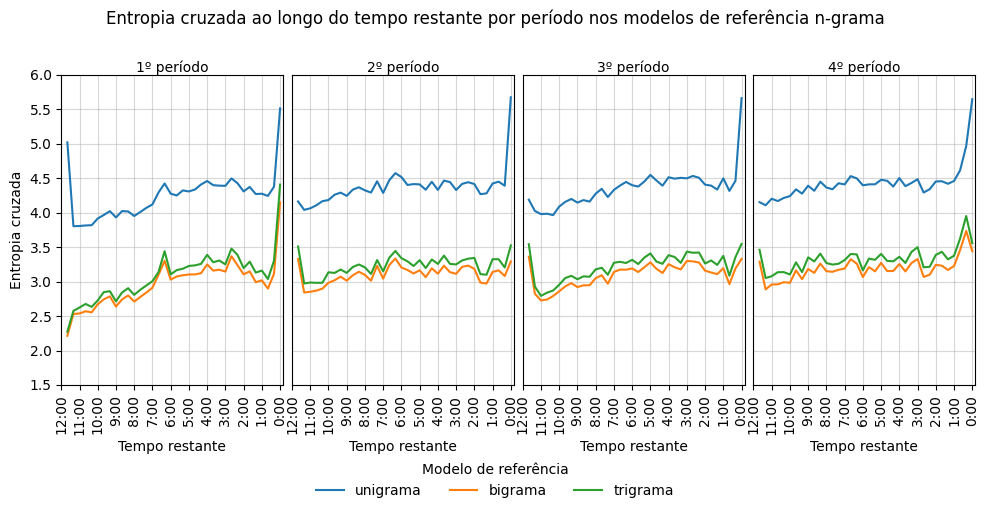

In [136]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

ordem_modelos = ["unigrama", "bigrama", "trigrama"]
for i in range(4):
    df_resultados_modelos_ref\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "cross_entropy")\
    .reindex(columns = ordem_modelos)\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 6]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize = 15, y = 0.98)
fig.suptitle("Entropia cruzada ao longo do tempo restante por período nos modelos de referência n-grama", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

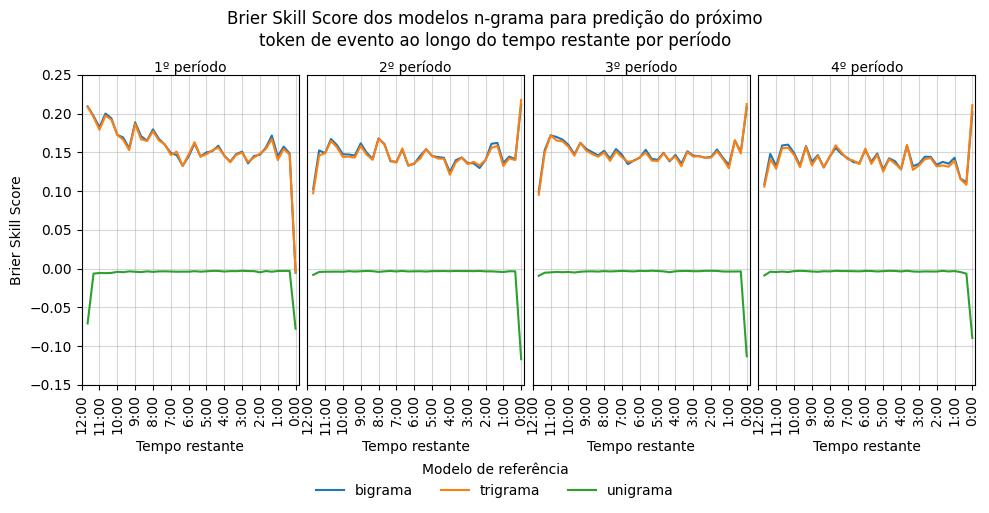

In [277]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):
    df_resultados_modelos_ref\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss")\
    .plot(ax = ax[i], legend = False)

    # df_resultados2_arquitetura_a\
    # .query("embedding_layer_size == 32")\
    # .sort_values("cross_entropy_mean")\
    # [["embedding_layer_size", "context_size", "num_layers", "dropout_rate", "layer_norm", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"]]\
    # .groupby("context_size")\
    # .apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
    # .query("index == 0")\
    # .reset_index()\
    # [["embedding_layer_size", "context_size", "num_layers", "dropout_rate", "layer_norm"]]\
    # .merge(df_resultados4_arquitetura_a, how = "inner")\
    # .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)\
    # .query("period == (@i + 1)")\
    # .pivot_table(index = "t1", columns = "context_size", values = "bss_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.15, 0.25]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score dos modelos n-grama para predição do próximo\ntoken de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [278]:
df_comparacao_arquiteturas_a_e = pd.concat(objs = [
    df_resultados4_arquitetura_a\
    .query("embedding_layer_size == 32 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & context_size == 5")\
    .query("period <= 4")\
    .assign(modelo = "melhor arquitetura A")\
    [["period", "cat_time", "bss_mean", "modelo"]],

    df_resultados4_arquitetura_e\
    .query("embedding_layer_size == 32 & num_layers == 3 & dropout_rate == 0 & layer_norm == 1")\
    .query("period <= 4")\
    .assign(modelo = "melhor arquitetura E")\
    [["period", "cat_time", "bss_mean", "modelo"]],

    # df_resultados4_arquitetura_c\
    # .query("embedding_layer_size == 32 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & set_covariables == 2")\
    # .query("period <= 4")\
    # .assign(modelo = "melhor arquitetura C")\
    # [["period", "cat_time", "bss_mean", "modelo"]],
    ], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int") / 10)

# .pivot_table(index = ["period", "cat_time"], columns = "modelo", values = "bss_mean")\
# .reset_index()\


In [279]:
df_comparacao_arquiteturas_a_e\
.assign(modelo = lambda df: df["modelo"].str.replace(" ", "_"))\
.pivot_table(index = ["period", "t1"], columns = "modelo", values = "bss_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.assign(ratio = lambda df: df["melhor_arquitetura_E"] / df["melhor_arquitetura_A"])\
.pivot_table(index = "t1", columns = "period", values = "ratio")\
.reset_index()\
.sort_values("t1", ascending = False)\
.describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

period,t1,1,2,3,4
count,36.000000,15.000000,15.000000,36.000000,36.000000
mean,350.000000,0.789584,1.111643,1.057560,1.063171
std,210.713075,0.788724,0.401445,0.181834,0.174121
min,0.000000,-2.026643,0.960787,0.971332,0.989643
1%,7.000000,-1.664282,0.962393,0.975719,0.990636
5%,35.000000,-0.214836,0.968817,0.986728,0.992739
10%,70.000000,0.734485,0.973206,0.997937,0.995382
25%,175.000000,1.001007,0.985949,1.007204,1.005265
50%,350.000000,1.011526,1.008097,1.015388,1.013445
75%,525.000000,1.019257,1.030742,1.029733,1.029419


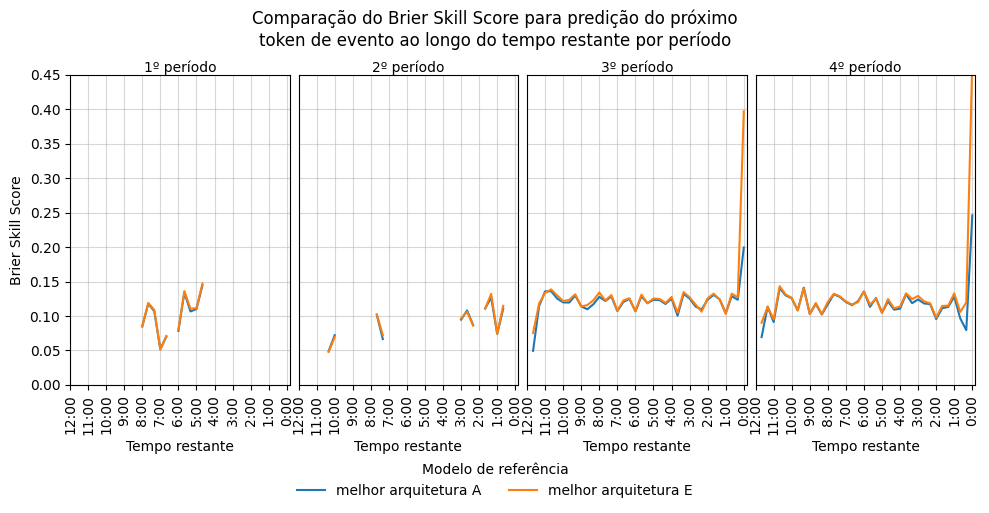

In [280]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    # pd.concat([df_comparacao_arquiteturas_a_e, 
    #         df_resultados_modelos_ref.query("modelo == 'bigrama'").rename(columns = {"bss": "bss_mean"})], axis = 0)\
    # .query("period == (@i + 1)")\
    # .pivot_table(index = "t1", columns = "modelo", values = "bss_mean")\
    # .plot(ax = ax[i], legend = False)

    df_comparacao_arquiteturas_a_e\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 0.45]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Comparação do Brier Skill Score para predição do próximo\ntoken de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [281]:
pd.set_option('display.max_columns', None)

In [282]:
df_resultados_modelos_ref

,period,t1,bss,modelo,cross_entropy
0,1,700.0,-0.070659,unigrama,5.021863
1,1,680.0,-0.006308,unigrama,3.803795
2,1,660.0,-0.005560,unigrama,3.807574
3,1,640.0,-0.005730,unigrama,3.814880
4,1,620.0,-0.005471,unigrama,3.819059
...,...,...,...,...,...
427,4,80.0,0.131587,trigrama,3.323652
428,4,60.0,0.139200,trigrama,3.375401
429,4,40.0,0.115647,trigrama,3.626278
430,4,20.0,0.108263,trigrama,3.951836


In [283]:
df_desempenho_modelos_ref_token_evento = pd.DataFrame(
    {"modelo": ["unigrama", "bigrama", "trigrama"], 
    "cross_entropy_mean": [4.394708, 3.101946, 3.229164],
    "cross_entropy_std": [0.022779, 0.021676, 0.026243],
    "bss_mean": [-0.00002846162770113736, 0.1560348238456925, 0.1548245502912339],
    "bss_std": [0.000010979391474114859, 0.002448110281124652, 0.0025091067101492724]})





In [284]:
df_desempenho_modelos_ref_token_evento

,modelo,cross_entropy_mean,cross_entropy_std,bss_mean,bss_std
0,unigrama,4.394708,0.022779,-0.000028,0.000011
1,bigrama,3.101946,0.021676,0.156035,0.002448
2,trigrama,3.229164,0.026243,0.154825,0.002509


In [285]:
df_desempenho_modelos_ref_token_evento\
.sort_values("cross_entropy_mean")\
.reset_index()\
.assign(CE = lambda df: df["cross_entropy_mean"].astype("str").str[:6] + " (" + df["cross_entropy_std"].astype("str").str[:6] + ")")\
.assign(CE = lambda df: df["CE"] + " [" + (df.index + 1).astype("str") + "]")\
.assign(BSS = lambda df: np.where(df["modelo"] == "unigrama", "0.0000", df["bss_mean"].astype("str").str[:6]))\
.sort_values("index")\
[["modelo", "CE", "BSS"]]

,modelo,CE,BSS
2,unigrama,4.3947 (0.0227) [3],0.0000
0,bigrama,3.1019 (0.0216) [1],0.1560
1,trigrama,3.2291 (0.0262) [2],0.1548


In [286]:
df_resultados1_arquitetura_a\
.sort_values("cross_entropy_mean")\
[["context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"]]\
.groupby("context_size")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.query("index == 0")\
.reset_index()\
.drop(columns = ["index", "level_1"])\
.reset_index(drop = True)\
.reset_index()\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.assign(CE = lambda df: df["cross_entropy_mean"].astype("str").str[:8] + " (" + df["cross_entropy_std"].astype("str").str[:6] + ")")\
.assign(CE = lambda df: df["CE"] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.assign(BSS = lambda df: df["bss_mean"].astype("str").str[:8] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("index")\
.drop(columns = ["index", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"])\
.reset_index(drop = True)


,context_size,embedding_layer_size,num_layers,dropout_rate,layer_norm,CE,BSS
0,1,64,5,0.0,True,3.013714 (0.0206) [3],0.156687 [3]
1,3,64,3,0.0,False,2.934978 (0.0212) [2],0.162449 [2]
2,5,32,3,0.0,False,2.925643 (0.0223) [1],0.162608 [1]


In [133]:
df_resultados1_arquitetura_d.sort_values("cross_entropy_mean").groupby("set_covariables")\
.apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "D")\
.T

,0
set_covariables,56
level_1,0
context_size,5
embedding_layer_size,32
num_hidden_neurons,50
num_layers,3
dropout_rate,0.0
layer_norm,False
bs_mean,0.79595
bs_std,0.002997


In [287]:
cols_ = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"]

pd.concat(objs = [
    df_resultados1_arquitetura_a.sort_values("cross_entropy_mean").iloc[[0]].assign(arquitetura = "A")[cols_],

    df_resultados1_arquitetura_b.sort_values("cross_entropy_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "B")[cols_],

    df_resultados1_arquitetura_b_fn.sort_values("cross_entropy_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "B (fn)")[cols_],

    df_resultados1_arquitetura_c.sort_values("cross_entropy_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "C")[cols_],

    df_resultados1_arquitetura_d.sort_values("cross_entropy_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "D")[cols_],

    df_resultados1_arquitetura_e.sort_values("cross_entropy_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "E")[cols_],
], axis = 0)\
.reset_index(drop = True)\
.reset_index()\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.assign(CE = lambda df: df["cross_entropy_mean"].astype("str").str[:8] + " (" + df["cross_entropy_std"].astype("str").str[:6] + ")")\
.assign(CE = lambda df: df["CE"] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.assign(BSS = lambda df: df["bss_mean"].astype("str").str[:8] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("index")\
.drop(columns = ["index", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"])\
.reset_index(drop = True)\
.assign(set_covariables = lambda df: np.where(df["set_covariables"].eq(56), 3, df["set_covariables"]))\
.assign(set_covariables = lambda df: np.where(df["set_covariables"].eq(0), '-', df["set_covariables"]))


,arquitetura,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,CE,BSS
0,A,5,32,-,50,3,0.0,False,2.925643 (0.0223) [9],0.162608 [9]
1,B,5,32,1,50,3,0.0,False,2.781246 (0.0178) [8],0.172645 [7]
2,B,5,32,2,50,3,0.0,False,2.778051 (0.0203) [6],0.173046 [3]
3,B (fn),5,32,1,50,3,0.0,False,2.781044 (0.0183) [7],0.172582 [8]
4,B (fn),5,32,2,50,3,0.0,False,2.77697 (0.0200) [4],0.173046 [4]
5,C,5,32,1,50,3,0.0,False,2.778000 (0.0190) [5],0.172957 [6]
6,C,5,32,2,50,3,0.0,False,2.776576 (0.0202) [3],0.172973 [5]
7,D,5,32,3,50,3,0.0,False,2.776383 (0.0196) [1],0.173174 [2]
8,E,5,32,3,50,3,0.0,True,2.776455 (0.0205) [2],0.173204 [1]


In [598]:

pd.concat(objs = [
    df_resultados1_arquitetura_a\
    .assign(arquitetura = "A")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),

    df_resultados1_arquitetura_b\
    .assign(arquitetura = "B")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),

    df_resultados1_arquitetura_b_fn\
    .assign(arquitetura = "B-ft")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),

    df_resultados1_arquitetura_c\
    .assign(arquitetura = "C")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),

    df_resultados1_arquitetura_d\
    .assign(arquitetura = "D")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),

    df_resultados1_arquitetura_e\
    .assign(arquitetura = "E")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "cross_entropy_mean")\
    .reset_index(),
    ], axis = 0)


layer_norm   arquitetura context_size embedding_layer_size set_covariables  \
dropout_rate                                                                 
num_layers                                                                   
0                      A            1                   32               0   
1                      A            1                   64               0   
2                      A            3                   32               0   
3                      A            3                   64               0   
4                      A            5                   32               0   
5                      A            5                   64               0   
0                      B            5                   32               1   
1                      B            5                   32               2   
2                      B            5                   64               1   
3                      B            5                   64               2   
0                   B-ft            5                   32               1   
1                   B-ft            5                   32               2   
2                   B-ft            5                   64               1   
3                   B-ft            5                   64               2   
0                      C            5                   32               1   
1                      C            5                   32               2   
2                      C            5                   64               1   
3                      C            5                   64               2   
0                      D            5                   32              56   
1                      D            5                   64              56   
0                      E            5                   32              56   
1                      E            5                   64              56   

layer_norm       False                                    True            \
dropout_rate       0.0                 0.3                 0.0             
num_layers           3         5         3         5         3         5   
0             3.015083  3.017967  3.038733  3.057862  3.016220  3.014771   
1             3.016147  3.015909  3.039080  3.055071  3.015543  3.013715   
2             2.934985  2.941213  2.963264  2.990371  2.943900  2.944551   
3             2.934978  2.939878  2.961317  2.985927  2.945427  2.944676   
4             2.925644  2.931277  2.951454  2.984105  2.937043  2.936365   
5             2.926884  2.933671  2.949557  2.980435  2.941374  2.940940   
0             2.781247  2.791747  2.821142  2.858821  2.790500  2.790366   
1             2.778052  2.783743  2.816201  2.854938  2.786142  2.786351   
2             2.784499  2.793307  2.820961  2.856575  2.793572  2.793984   
3             2.783326  2.793738  2.815131  2.848531  2.789273  2.790618   
0             2.781044  2.789978  2.814849  2.845861  2.793550  2.795001   
1             2.776970  2.784889  2.810126  2.840152  2.790621  2.790655   
2             2.787186  2.795351  2.813220  2.842443  2.798629  2.799794   
3             2.784867  2.797305  2.808548  2.836047  2.795284  2.797353   
0             2.778000  2.788520  2.816241  2.848438  2.785515  2.787673   
1             2.776576  2.786320  2.814488  2.848453  2.787572  2.787081   
2             2.781186  2.793225  2.814160  2.850296  2.790657  2.790598   
3             2.781192  2.792527  2.814719  2.847284  2.791322  2.791845   
0             2.776383  2.782804  2.819091  2.854264  2.786454  2.786828   
1             2.777992  2.787980  2.816173  2.846893  2.790152  2.790748   
0             2.779069  2.793815  2.868005  2.904500  2.776455  2.778314   
1             2.783023  2.793368  2.864379  2.899240  2.781884  2.782939   

layer_norm                        
dropout_rate       0.3            
num_layers           3         5  
0             3.028288  3.054920  
1       

In [621]:
pd.concat(objs = [
    df_resultados3_arquitetura_b\
    .query("period <= 4")\
    .assign(arquitetura = "B")\
    [["arquitetura", "period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "bss_mean"]],

    df_resultados3_arquitetura_b_fn\
    .query("period <= 4")\
    .assign(arquitetura = "B-fn")\
    [["arquitetura", "period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "bss_mean"]],

    df_resultados3_arquitetura_c\
    .query("period <= 4")\
    .assign(arquitetura = "C")\
    [["arquitetura", "period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "bss_mean"]],

    df_resultados3_arquitetura_d\
    .query("period <= 4")\
    .assign(arquitetura = "D")\
    [["arquitetura", "period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "bss_mean"]],

    df_resultados3_arquitetura_e\
    .query("period <= 4")\
    .assign(arquitetura = "E")\
    [["arquitetura", "period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "bss_mean"]]

], axis = 0)\
.merge(
    df_resultados3_arquitetura_a\
    .query("context_size == 5 & period <= 4")\
    .assign(bss_ref = lambda df: df["bss_mean"])\
    [["period", "cat_time", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "bss_ref"]],
    how = "left")\
.assign(bss_ratio = lambda df: df["bss_mean"] - df["bss_ref"])\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.query("t1 <= 0")\
.sort_values("bss_ratio", ascending = False)
# .groupby(["arquitetura", "context_size", "embedding_layer_size", "num_layers", "dropout_rate", "layer_norm", "set_covariables"], as_index = False, dropna = False)\
# ["bss_ratio"].describe(percentiles = [0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])\
# .sort_values("50%", ascending = False)



,arquitetura,period,cat_time,context_size,embedding_layer_size,num_layers,dropout_rate,layer_norm,set_covariables,bss_mean,bss_ref,bss_ratio,t1
16133,E,1,0-200,5,32,5,0.0,True,56,0.254899,0.001926,0.252974,0.0
8,B,1,0-200,5,32,3,0.0,False,2,0.257089,0.005815,0.251274,0.0
13824,D,1,0-200,5,32,3,0.0,False,56,0.256922,0.005815,0.251107,0.0
16137,E,1,0-200,5,64,3,0.0,True,56,0.254211,0.003246,0.250965,0.0
13828,D,1,0-200,5,32,5,0.0,False,56,0.254548,0.004581,0.249966,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
17870,E,4,0-200,5,64,5,0.3,False,56,0.286260,0.197523,0.088737,0.0
17859,E,4,0-200,5,32,3,0.3,True,56,0.302681,0.214279,0.088402,0.0
17858,E,4,0-200,5,32,3,0.3,False,56,0.298163,0.211294,0.086869,0.0
17863,E,4,0-200,5,32,5,0.3,True,56,0.279180,0.192383,0.086797,0.0


In [120]:
cols_ = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

df_resultados3_agregado_melhores_modelos = pd.concat(objs = [

    df_resultados_modelos_ref.query("modelo == 'bigrama'")[["period", "t1", "bss", "modelo"]],

    df_resultados1_arquitetura_a.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "A")\
    [cols_]\
    .merge(df_resultados3_arquitetura_a, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 

    df_resultados1_arquitetura_b.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B")\
    [cols_]\
    .merge(df_resultados3_arquitetura_b, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 

    df_resultados1_arquitetura_b_fn.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B-ft")\
    [cols_]\
    .merge(df_resultados3_arquitetura_b_fn, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 

    df_resultados1_arquitetura_c.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "C")\
    [cols_]\
    .merge(df_resultados3_arquitetura_c, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 

    df_resultados1_arquitetura_d.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "D")\
    [cols_]\
    .merge(df_resultados3_arquitetura_d, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 

    df_resultados1_arquitetura_e.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "E")\
    [cols_]\
    .merge(df_resultados3_arquitetura_e, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean"]], 
], axis = 0)\
.assign(t1_ = lambda df: df["cat_time"].fillna("0").str.split("-").str[0].astype("int") / 10)\
.assign(t1 = lambda df: df["t1"].fillna(df["t1_"]))\
.assign(bss_mean = lambda df: df["bss_mean"].fillna(df["bss"]))\
.assign(modelo = lambda df: df["modelo"].fillna(df["arquitetura"]))\
.drop(columns = ["t1_", "bss", "arquitetura", "cat_time"])


In [129]:
df_resultados3_agregado_melhores_modelos\
.query("t1 == 0")\
.reset_index(drop = True)\
.sort_values("bss_mean", ascending = False)\
.groupby("period")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.assign(ranking = lambda df: df["index"] + 1)\
.assign(metrica = lambda df: df["bss_mean"].astype("str").str[:7] + " [" + df['ranking'].astype("str") + "]")\
.pivot_table(index = ["modelo"], columns = ["period"], values = "metrica", aggfunc = lambda x: x)


period,1,2,3,4
modelo,,,,
A,0.00581 [6],0.22884 [6],0.22426 [6],0.23510 [6]
B,0.25708 [1],0.41010 [2],0.41008 [2],0.37332 [5]
B-ft,0.25351 [3],0.40973 [3],0.41017 [1],0.37426 [4]
C,0.24752 [5],0.40769 [5],0.40419 [5],0.37726 [2]
D,0.25692 [2],0.40905 [4],0.40686 [4],0.37563 [3]
E,0.25177 [4],0.41280 [1],0.40821 [3],0.38635 [1]
bigrama,-0.0051 [7],0.21178 [7],0.20805 [7],0.20213 [7]


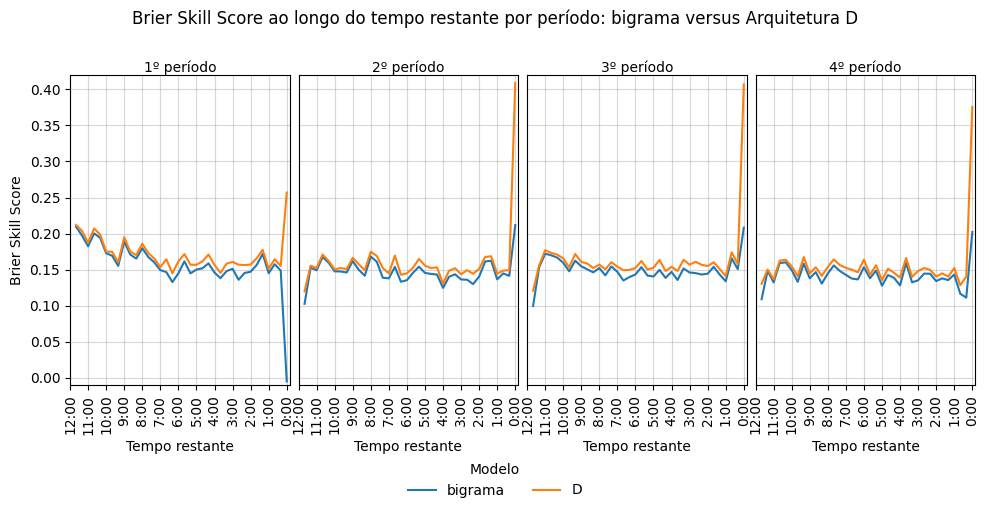

In [289]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados3_agregado_melhores_modelos\
    .query("period == (@i + 1)")\
    .query("modelo == 'bigrama'")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    df_resultados3_agregado_melhores_modelos\
    .query("period == (@i + 1)")\
    .query("modelo == 'D'")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)


    bounds_y = [-0.01, 0.42]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período: bigrama versus Arquitetura D", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [290]:
cols_ = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

df_resultados4_agregado_melhores_modelos = pd.concat(objs = [

    df_resultados1_arquitetura_a.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "A")\
    [cols_]\
    .merge(df_resultados4_arquitetura_a, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],

    df_resultados1_arquitetura_b.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B")\
    [cols_]\
    .merge(df_resultados4_arquitetura_b, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],

    df_resultados1_arquitetura_b_fn.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B-ft")\
    [cols_]\
    .merge(df_resultados4_arquitetura_b_fn, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],

    df_resultados1_arquitetura_c.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "C")\
    [cols_]\
    .merge(df_resultados4_arquitetura_c, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],

    df_resultados1_arquitetura_d.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "D")\
    [cols_]\
    .merge(df_resultados4_arquitetura_d, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],

    df_resultados1_arquitetura_e.sort_values("cross_entropy_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "E")\
    [cols_]\
    .merge(df_resultados4_arquitetura_e, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "cat_dif", "bss_mean", "cross_entropy_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].fillna("0").str.split("-").str[0].astype("int") / 10)\
.drop(columns = ["cat_time"])


In [291]:
df_resultados4_agregado_melhores_modelos.query("period == 4 & t1 == 00")\
.pivot_table(index = ["cat_dif"], columns = "arquitetura", values = "bss_mean")

arquitetura,A,B,B-ft,C,D,E
cat_dif,,,,,,
0,0.196010,0.572118,0.568094,0.563466,0.526897,0.577814
1,0.331156,0.615807,0.621701,0.635360,0.602840,0.649357
2,0.319709,0.472889,0.469848,0.472169,0.432339,0.459515
3,0.191012,0.265329,0.271037,0.280169,0.272678,0.301644
4,0.160855,0.256284,0.256386,0.254980,0.267743,0.266283
5,0.227187,0.290310,0.291695,0.303463,0.306308,0.308372
6,0.245387,0.416960,0.418407,0.412292,0.409656,0.422744
7,0.280600,0.596342,0.598847,0.602262,0.588291,0.600667
8,0.263381,0.622717,0.622923,0.632865,0.619611,0.655481


In [292]:
df_resultados4_agregado_melhores_modelos\
.query("bss_mean >= 0")\
.sort_values(["period", "t1", "cat_dif", "bss_mean"], ascending = [True, False, True, False])\
.groupby(["period", "t1", "cat_dif"])\
.apply(lambda df: df.reset_index(drop = True).reset_index().rename(columns = {"index": "posto"}), include_groups = False)\
.reset_index()\
.assign(posto = lambda df: df["posto"] + 1)\
.sort_values(["period", "t1", "cat_dif", "bss_mean"], ascending = [True, False, True, False])\
.groupby(["arquitetura", "cat_dif"], as_index = False)["posto"].mean()\
.groupby(["cat_dif"])\
.apply(lambda df: df.sort_values("posto").reset_index(drop = True).reset_index(), include_groups = False)\
.assign(posto = lambda df: df["posto"].astype('str').str[:6] + " [" + (1  + df["index"]).astype("str") + "]")\
.reset_index()\
.pivot_table(index = "arquitetura", columns = "cat_dif", values = "posto", aggfunc = lambda x: x)   

cat_dif,0,1,2,3,4,5,6,7,8
arquitetura,,,,,,,,,
A,3.6527 [5],4.384 [6],4.1185 [6],4.5177 [6],4.6805 [6],4.4468 [6],4.5036 [6],4.6356 [6],4.4418 [6]
B,3.375 [2],3.4444 [5],3.2846 [2],3.2112 [1],3.3125 [4],3.1418 [1],3.4130 [4],3.2656 [3],3.3139 [3]
B-ft,4.0547 [6],3.2460 [2],3.3503 [4],3.2323 [2],3.2430 [3],3.3617 [4],3.3260 [3],3.2480 [2],3.5116 [5]
C,3.4305 [4],3.3888 [3],3.1970 [1],3.2605 [3],3.2361 [2],3.4255 [5],3.4565 [5],3.2713 [4],3.4827 [4]
D,2.8630 [1],3.0952 [1],3.2919 [3],3.2676 [4],3.1458 [1],3.2695 [2],3.1666 [2],3.2093 [1],3.2758 [2]
E,3.4305 [3],3.4285 [4],3.7205 [5],3.5 [5],3.3819 [5],3.3546 [3],3.1231 [1],3.3488 [5],2.9310 [1]


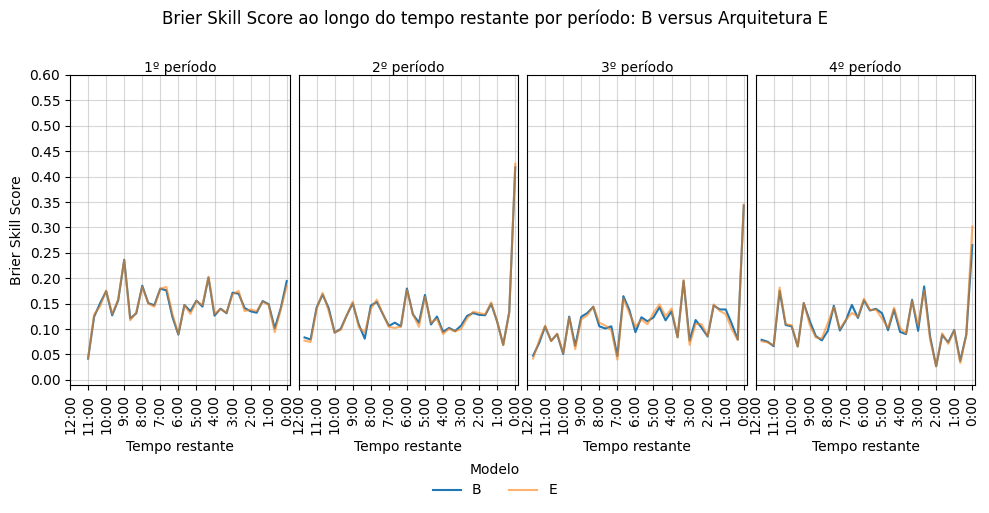

In [293]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados4_agregado_melhores_modelos\
    .query("period == (@i + 1)")\
    .query("arquitetura == 'B' & cat_dif == 3")\
    .pivot_table(index = "t1", columns = "arquitetura", values = "bss_mean")\
    .plot(ax = ax[i], legend = False)

    df_resultados4_agregado_melhores_modelos\
    .query("period == (@i + 1)")\
    .query("arquitetura == 'E' & cat_dif == 3")\
    .pivot_table(index = "t1", columns = "arquitetura", values = "bss_mean")\
    .plot(ax = ax[i], legend = False, alpha = 0.6)

    bounds_y = [-0.01, 0.6]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score ao longo do tempo restante por período: B versus Arquitetura E", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [294]:
df_resultados4_agregado_melhores_modelos

,arquitetura,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,period,cat_dif,bss_mean,cross_entropy_mean,t1
0,A,5,32,0,50,3,0.0,False,1,0,-0.465938,4.408409,0.0
1,A,5,32,0,50,3,0.0,False,1,1,-0.035089,4.060429,0.0
2,A,5,32,0,50,3,0.0,False,1,2,-0.030537,3.995563,0.0
3,A,5,32,0,50,3,0.0,False,1,3,-0.030817,4.137746,0.0
4,A,5,32,0,50,3,0.0,False,1,4,0.004130,3.869413,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222,E,5,32,56,50,3,0.0,True,4,4,0.101176,2.962720,80.0
1223,E,5,32,56,50,3,0.0,True,4,5,0.125820,2.599790,80.0
1224,E,5,32,56,50,3,0.0,True,4,6,0.123789,3.030941,80.0
1225,E,5,32,56,50,3,0.0,True,4,7,0.126394,2.955522,80.0


In [295]:
df_resultados2_arquitetura_a\
.query("embedding_layer_size == 32")\
.sort_values("cross_entropy_mean", ascending = True)\
.groupby("context_size")\
.apply(lambda df: df.reset_index(drop = True).reset_index().query("index == 0"), include_groups = False)\
.reset_index()\
[["context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]]\
.merge(df_resultados4_arquitetura_a, how = "inner")\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
.query("t1 == 0 & period <= 4")\
[["num_layers", "dropout_rate", "layer_norm", "context_size", "period", "bss_mean", "bss_std"]]\
.sort_values("bss_mean", ascending = False)\
.groupby("period")\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index()\
.set_index("index")\
.assign(metrica = lambda df: df["bss_mean"].astype(str).str[:6] + " (" + df["bss_std"].astype(str).str[:5] + ") [" + (1 + df.index).astype(str) + "]")\
.pivot_table(index = ["num_layers", "dropout_rate", "layer_norm", "context_size"], columns = "period", values = "metrica", aggfunc= lambda x: x)\
.reset_index()\
.sort_values("context_size")

period,num_layers,dropout_rate,layer_norm,context_size,1,2,3,4
0,3,0.0,False,1,"[-0.006 (0.013) [7], -0.006 (0.082) [8], -0.01...","[0.2515 (0.024) [5], 0.2403 (0.075) [7], 0.226...","[0.2522 (0.058) [3], 0.2123 (0.037) [11], 0.20...","[0.2741 (0.083) [6], 0.2609 (0.041) [10], 0.25..."
1,3,0.0,False,3,"[0.0020 (0.014) [3], 0.0010 (0.088) [5], -0.00...","[0.2653 (0.031) [2], 0.2557 (0.073) [4], 0.237...","[0.2597 (0.055) [2], 0.2292 (0.027) [5], 0.219...","[0.3134 (0.031) [3], 0.3098 (0.063) [4], 0.273..."
2,3,0.0,False,5,"[0.0041 (0.014) [1], 0.0032 (0.080) [2], 0.001...","[0.2670 (0.031) [1], 0.2558 (0.069) [3], 0.242...","[0.2636 (0.054) [1], 0.2353 (0.028) [4], 0.229...","[0.3311 (0.061) [1], 0.3197 (0.032) [2], 0.280..."


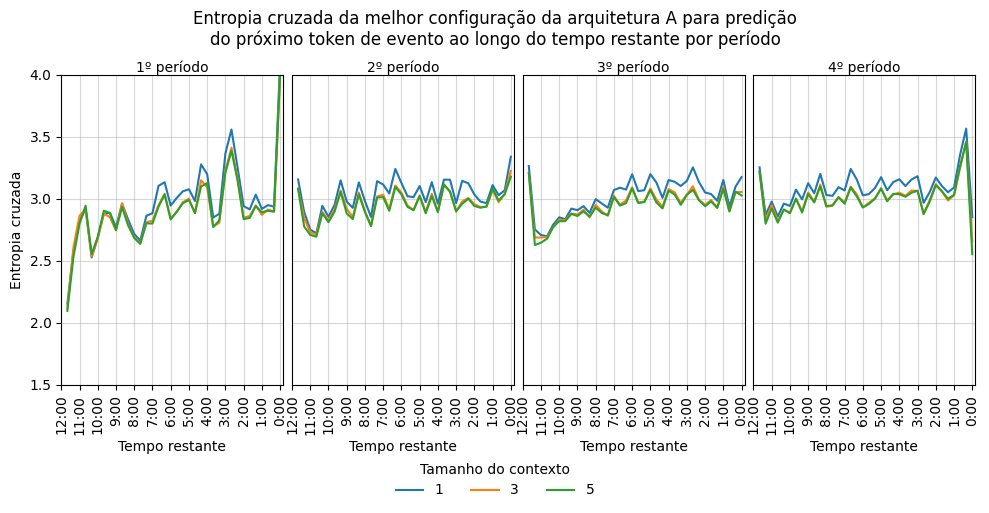

In [296]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados4_arquitetura_a\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "cross_entropy_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Entropia cruzada da melhor configuração da arquitetura A para predição\ndo próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

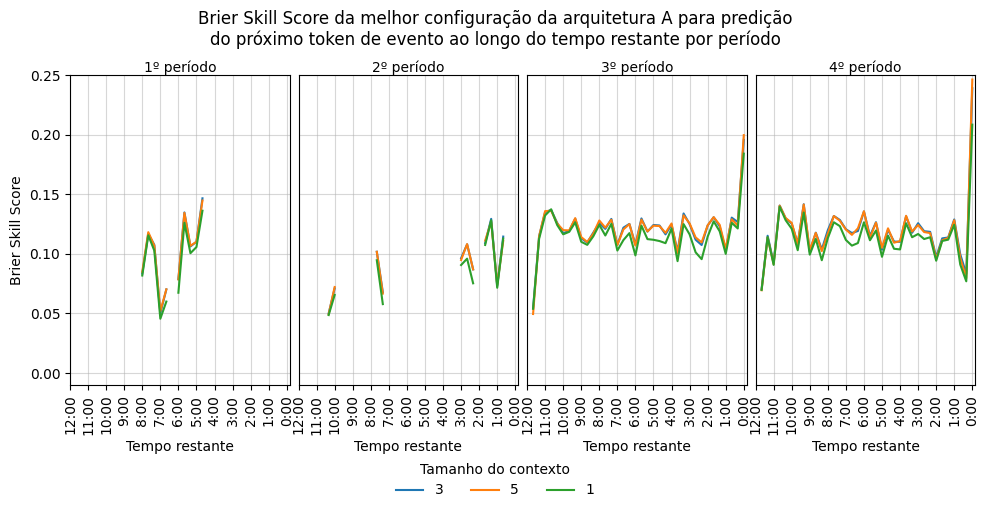

In [297]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados4_arquitetura_a\
    .query("context_size in [3, 5] & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    df_resultados4_arquitetura_a\
    .query("context_size in [1] & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)


    bounds_y = [-0.01, 0.25]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura A para predição\ndo próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

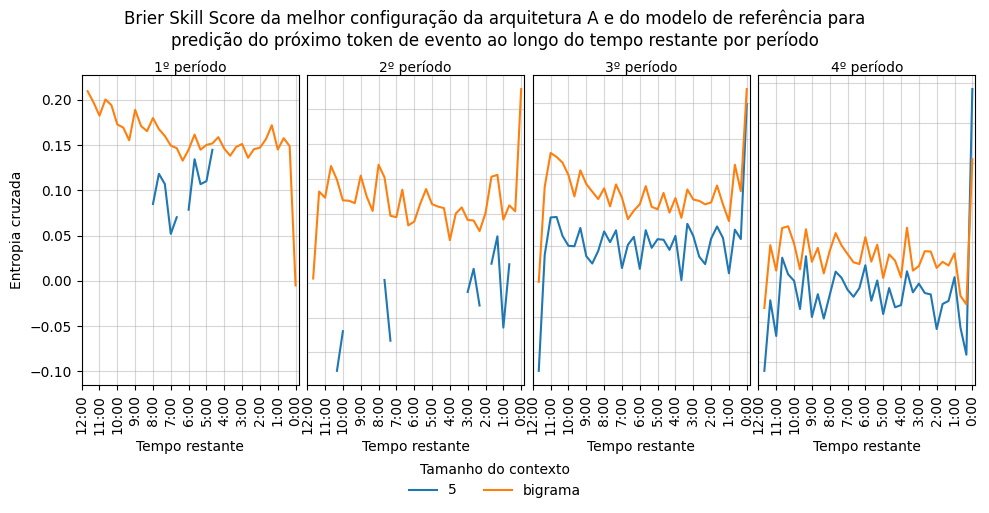

In [298]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados4_arquitetura_a\
    .query("context_size in [1, 3, 5] & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & dropout_rate == 0 & layer_norm == 0 & context_size == 5")\
    .query("period == (@i + 1)")\
    .assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
    .pivot_table(index = "t1", columns = "context_size", values = "bss_mean")\
    .plot(ax = ax[i], legend=False)

    df_resultados_modelos_ref\
    .query('modelo == "bigrama"')\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss")\
    .plot(ax = ax[i], legend=False)

    # bounds_y = [1.5, 4]
    # ax[i].set_ylim(bounds_y)
    # ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura A e do modelo de referência para\npredição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Tamanho do contexto", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [299]:
df_bss_comparison_event = pd.concat([
    
    df_resultados4_arquitetura_a\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0")\
    .assign(arquitetura = "A")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_b\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_b_fn\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B (fine-tuning)")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_c\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "C")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_d\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "D")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_e\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 1 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "E")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
[["arquitetura", "period", "cat_time", "t1", "bss_mean"]]\
.pivot_table(index = ["period", "cat_time", "t1"], columns = "arquitetura", values = "bss_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.merge(df_resultados_modelos_ref.pivot_table(index = ["period", "t1"], columns = "modelo", values = "bss").reset_index(), how = "left")


    

In [300]:
df_ce_comparison_event = pd.concat([
    
    df_resultados4_arquitetura_a\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0")\
    .assign(arquitetura = "A")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_b\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_b_fn\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B (fine-tuning)")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_c\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "C")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_d\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "D")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_e\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 3 & layer_norm == 1 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "E")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
[["arquitetura", "period", "cat_time", "t1", "cross_entropy_mean"]]\
.pivot_table(index = ["period", "cat_time", "t1"], columns = "arquitetura", values = "cross_entropy_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.merge(df_resultados_modelos_ref.pivot_table(index = ["period", "t1"], columns = "modelo", values = "cross_entropy").reset_index(), how = "left")


    

In [301]:
df_bss_comparison_event\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])\
.assign(best_ngram = lambda df: df[["unigrama", "bigrama", "trigrama"]].max(axis = 1))\
.assign(best_ngram = lambda df: np.where(df["best_ngram"] <= 0.001, 0.001, df["best_ngram"]))\
.assign(ratio_a = lambda df: df["A"] / df["best_ngram"])\
.assign(ratio_b = lambda df: df["B"] / df["best_ngram"])\
.assign(ratio_b_fn = lambda df: df["B (fine-tuning)"] / df["best_ngram"])\
.assign(ratio_c = lambda df: df["C"] / df["best_ngram"])\
.assign(ratio_d = lambda df: df["D"] / df["best_ngram"])\
.assign(ratio_e = lambda df: df["E"] / df["best_ngram"])\
[["ratio_a", "ratio_b", "ratio_b_fn", "ratio_c", "ratio_d", "ratio_e"]].describe()

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\li

,ratio_a,ratio_b,ratio_b_fn,ratio_c,ratio_d,ratio_e
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,-inf,-inf,-inf,-inf,-inf,-inf
std,NaN,NaN,NaN,NaN,NaN,NaN
min,-inf,-inf,-inf,-inf,-inf,-inf
25%,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.737143,0.758178,0.762562,0.764492,0.765332,0.764781
75%,0.826521,0.844782,0.841898,0.844436,0.847159,0.844941
max,1.165809,190.435213,189.399683,183.610465,196.775090,201.598979


In [302]:
df_ce_comparison_event\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])\
.assign(best_ngram = lambda df: df[["unigrama", "bigrama", "trigrama"]].min(axis = 1))\
.assign(ratio_a = lambda df: 1 - (df["A"] / df["best_ngram"]))\
.assign(ratio_b = lambda df: 1 - (df["B"] / df["best_ngram"]))\
.assign(ratio_b_fn = lambda df: 1 - (df["B (fine-tuning)"] / df["best_ngram"]))\
.assign(ratio_c = lambda df: 1 - (df["C"] / df["best_ngram"]))\
.assign(ratio_d = lambda df: 1 - (df["D"] / df["best_ngram"]))\
.assign(ratio_e = lambda df: 1 - (df["E"] / df["best_ngram"]))\
[["ratio_a", "ratio_b", "ratio_b_fn", "ratio_c", "ratio_d", "ratio_e"]].describe()

,ratio_a,ratio_b,ratio_b_fn,ratio_c,ratio_d,ratio_e
count,144.000000,144.000000,144.000000,144.000000,144.000000,144.000000
mean,0.044203,0.084542,0.084720,0.085290,0.085650,0.084749
std,0.040509,0.075011,0.075207,0.075009,0.074580,0.076449
min,-0.146375,-0.081080,-0.084423,-0.088407,-0.079099,-0.086237
25%,0.028590,0.056976,0.057715,0.056409,0.057792,0.057188
50%,0.049593,0.076581,0.076591,0.075875,0.076101,0.076045
75%,0.067122,0.095245,0.096164,0.096605,0.095333,0.096272
max,0.257959,0.555795,0.557438,0.561952,0.555542,0.569650


In [303]:
df_bss_comparison_event\
.query("t1 <= 40")\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])

A         B  B (fine-tuning)         C         D  \
period t1                                                              
1      40.0 -0.005402 -0.004014        -0.007650 -0.002731 -0.009031   
       20.0      -inf      -inf             -inf      -inf      -inf   
       0.0  -0.099474  0.190435         0.189400  0.183610  0.196775   
2      40.0  0.110708  0.115058         0.114008  0.113756  0.114594   
       20.0      -inf      -inf             -inf      -inf      -inf   
       0.0   0.145519  0.361449         0.360859  0.362738  0.359961   
3      40.0  0.128931  0.132420         0.133481  0.131131  0.132265   
       20.0  0.123659  0.128799         0.128586  0.123993  0.126944   
       0.0   0.199500  0.399389         0.399554  0.392561  0.395736   
4      40.0  0.096557  0.101565         0.101208  0.101826  0.103573   
       20.0  0.079558  0.112164         0.113292  0.115127  0.108947   
       0.0   0.246144  0.456529         0.457660  0.461892  0.447374   

                    E   bigrama  trigrama  unigrama  
period t1                                            
1      40.0 -0.005693  0.157489  0.154538 -0.002850  
       20.0      -inf  0.148681  0.147196 -0.002832  
       0.0   0.201599 -0.005127 -0.004053 -0.077471  
2      40.0  0.114920  0.144686  0.142413 -0.003297  
       20.0      -inf  0.141290  0.140139 -0.003396  
       0.0   0.372257  0.211789  0.217792 -0.116775  
3      40.0  0.132462  0.165487  0.165723 -0.003646  
       20.0  0.127251  0.150580  0.148663 -0.003479  
       0.0   0.397155  0.208056  0.212405 -0.112978  
4      40.0  0.105906  0.116498  0.115647 -0.004316  
       20.0  0.119662  0.111125  0.108263 -0.006422  
       0.0   0.471320  0.202132  0.211136 -0.089421

In [304]:
df_bss_comparison_event\
.set_index(["period", "cat_time", "t1"])\
.stack().reset_index()\
.rename(columns = {"level_3": "arquitetura", 0: "bss"})\
.sort_values(["period", "t1", "bss"], ascending = [True, False, False])\
.groupby(["period", "cat_time", "t1"])\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index(["period", "cat_time", "t1"])\
.assign(index = lambda df: df["index"] + 1)\
.groupby("arquitetura")["index"].describe()\
.sort_values("mean")

,count,mean,std,min,25%,50%,75%,max
arquitetura,,,,,,,,
bigrama,144.0,1.437500,1.210206,1.0,1.00,1.0,1.0,8.0
trigrama,144.0,2.000000,1.064362,1.0,2.00,2.0,2.0,8.0
B,144.0,5.083333,1.248776,2.0,4.75,5.0,6.0,8.0
D,144.0,5.506944,1.975361,2.0,4.00,5.0,8.0,9.0
B (fine-tuning),144.0,5.541667,1.403667,1.0,5.00,6.0,6.0,9.0
C,144.0,5.652778,1.648561,1.0,4.00,6.0,7.0,8.0
E,144.0,6.263889,2.409150,1.0,4.00,7.0,9.0,9.0
A,144.0,6.340278,1.813559,3.0,4.00,7.0,8.0,9.0
unigrama,144.0,7.173611,2.751554,3.0,3.00,9.0,9.0,9.0


In [305]:
df_bss_comparison_event\
.set_index(["period", "cat_time", "t1"])\
.stack().reset_index()\
.rename(columns = {"level_3": "arquitetura", 0: "bss"})\
.sort_values(["period", "t1", "bss"], ascending = [True, False, False])\
.groupby(["period", "cat_time", "t1"])\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index(["period", "cat_time", "t1"])\
.assign(index = lambda df: df["index"] + 1)\
.groupby(["arquitetura", "index"], as_index = False, dropna = False).size()\
.assign(prop = lambda df: 100 * df["size"] / 144)\
.pivot_table(index = "arquitetura", columns ="index", values = "prop", fill_value = '-')

C:\Users\User\AppData\Local\Temp\ipykernel_9520\1775889407.py:12: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .pivot_table(index = "arquitetura", columns ="index", values = "prop", fill_value = '-')


index,1,2,3,4,5,6,7,8,9
arquitetura,,,,,,,,,
A,-,-,1.388889,30.555556,4.861111,5.555556,11.805556,45.138889,0.694444
B,-,0.694444,13.194444,11.111111,42.361111,20.833333,8.333333,3.472222,-
B (fine-tuning),0.694444,0.694444,9.027778,13.194444,12.5,44.444444,13.194444,5.555556,0.694444
C,0.694444,2.083333,11.805556,13.888889,11.805556,10.416667,46.527778,2.777778,-
D,-,0.694444,18.75,20.833333,15.972222,8.333333,4.166667,30.555556,0.694444
E,2.777778,-,16.666667,9.027778,11.805556,8.333333,11.805556,10.416667,29.166667
bigrama,76.388889,19.444444,-,-,0.694444,-,2.777778,0.694444,-
trigrama,19.444444,76.388889,-,-,-,2.083333,1.388889,0.694444,-
unigrama,-,-,29.166667,1.388889,-,-,-,0.694444,68.75


In [306]:
df_ce_comparison_event\
.set_index(["period", "cat_time", "t1"])\
.stack().reset_index()\
.rename(columns = {"level_3": "arquitetura", 0: "cross_entropy"})\
.sort_values(["period", "t1", "cross_entropy"], ascending = [True, False, True])\
.groupby(["period", "cat_time", "t1"])\
.apply(lambda df: df.reset_index(drop = True).reset_index(), include_groups = False)\
.reset_index(["period", "cat_time", "t1"])\
.assign(index = lambda df: df["index"] + 1)\
.groupby("arquitetura")["index"].describe()\
.sort_values("mean")


,count,mean,std,min,25%,50%,75%,max
arquitetura,,,,,,,,
C,144.0,2.805556,1.400688,1.0,2.0,3.0,4.0,7.0
D,144.0,2.805556,1.483135,1.0,1.0,3.0,4.0,5.0
B (fine-tuning),144.0,3.055556,1.227755,1.0,2.0,3.0,4.0,5.0
E,144.0,3.270833,1.618161,1.0,2.0,3.0,5.0,6.0
B,144.0,3.284722,1.417489,1.0,2.0,3.0,4.0,7.0
A,144.0,6.104167,0.483558,4.0,6.0,6.0,6.0,8.0
bigrama,144.0,6.784722,0.969198,1.0,7.0,7.0,7.0,7.0
trigrama,144.0,7.888889,0.720442,2.0,8.0,8.0,8.0,8.0
unigrama,144.0,9.000000,0.000000,9.0,9.0,9.0,9.0,9.0


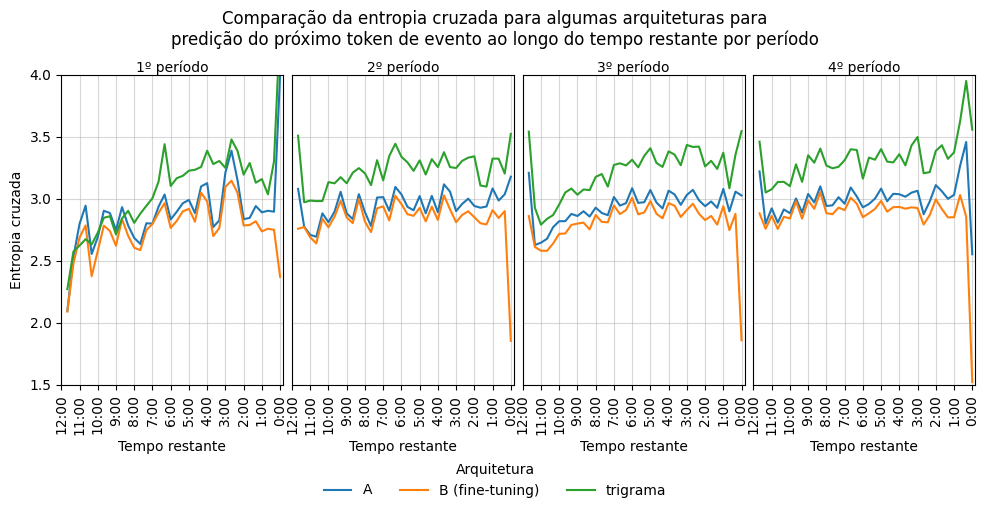

In [307]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_ce_comparison_event\
    .query("period == (@i + 1)")\
    .set_index("t1")\
    [["A", "B (fine-tuning)", "trigrama"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.5, 4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Entropia cruzada")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Comparação da entropia cruzada para algumas arquiteturas para\npredição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Arquitetura", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

### Gráficos Tempo gasto

In [24]:
df_resultados1_arquitetura_e_TIME.sort_values("mae_mean").groupby("set_covariables")\
.apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "B")[cols_]

NameError: name 'cols_' is not defined

In [25]:

pd.concat(objs = [

    df_resultados1_arquitetura_b_TIME\
    .assign(arquitetura = "B")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "mae_mean")\
    .reset_index(),

    df_resultados1_arquitetura_b_fn_TIME\
    .assign(arquitetura = "B-ft")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "mae_mean")\
    .reset_index(),

    df_resultados1_arquitetura_c_TIME\
    .assign(arquitetura = "C")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "mae_mean")\
    .reset_index(),

    df_resultados1_arquitetura_d_TIME\
    .assign(arquitetura = "D")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "mae_mean")\
    .reset_index(),

    df_resultados1_arquitetura_e_TIME\
    .assign(arquitetura = "E")\
    .pivot_table(index = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables"], columns = ["layer_norm", "dropout_rate", "num_layers"], values = "mae_mean")\
    .reset_index(),
    ], axis = 0)


NameError: name 'df_resultados1_arquitetura_b_TIME' is not defined

In [26]:
df_resultados1_arquitetura_e_TIME.sort_values("mae_mean").groupby("set_covariables")\
.apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "E")\
.T

,0
set_covariables,56
level_1,5
context_size,5
embedding_layer_size,32
num_hidden_neurons,50
num_layers,5
dropout_rate,0.0
layer_norm,True
bs_mean,0.796758
bs_std,0.004342


In [27]:
cols_ = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", 
         "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std", "mae_mean", "mae_std"]

pd.concat(objs = [

    df_resultados1_arquitetura_b_TIME.sort_values("mae_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "B")[cols_],

    df_resultados1_arquitetura_b_fn_TIME.sort_values("mae_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "B-ft")[cols_],

    df_resultados1_arquitetura_c_TIME.sort_values("mae_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "C")[cols_],

    df_resultados1_arquitetura_d_TIME.sort_values("mae_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "D")[cols_],

    df_resultados1_arquitetura_e_TIME.sort_values("mae_mean").groupby("set_covariables")\
    .apply(lambda df: df.iloc[[0]], include_groups = False).reset_index().assign(arquitetura = "E")[cols_],
], axis = 0)\
.reset_index(drop = True)\
.reset_index()\
.sort_values("mae_mean", ascending = True)\
.reset_index(drop = True)\
.assign(MAE = lambda df: df["mae_mean"].astype("str").str[:8] + " (" + df["mae_std"].astype("str").str[:6] + ")")\
.assign(MAE = lambda df: df["MAE"] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("cross_entropy_mean", ascending = True)\
.reset_index(drop = True)\
.assign(CE = lambda df: df["cross_entropy_mean"].astype("str").str[:8] + " (" + df["cross_entropy_std"].astype("str").str[:6] + ")")\
.assign(CE = lambda df: df["CE"] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("bss_mean", ascending = False)\
.reset_index(drop = True)\
.assign(BSS = lambda df: df["bss_mean"].astype("str").str[:8] + " [" + (df.index + 1).astype("str") + "]")\
.sort_values("index")\
.drop(columns = ["index", "cross_entropy_mean", "cross_entropy_std", "bss_mean", "bss_std"])\
.reset_index(drop = True)\
.assign(set_covariables = lambda df: np.where(df["set_covariables"].eq(56), 3, df["set_covariables"]))\
.assign(set_covariables = lambda df: np.where(df["set_covariables"].eq(0), '-', df["set_covariables"]))


NameError: name 'df_resultados1_arquitetura_b_TIME' is not defined

In [28]:
df_resultados_modelos_ref_TIME_SIZE

,period,t1,bss,modelo,cross_entropy,mae
0,1,700.0,0.289853,bigrama,2.039881,33.040812
1,1,680.0,0.064710,bigrama,2.709568,36.892102
2,1,660.0,0.062951,bigrama,2.701127,37.432224
3,1,640.0,0.060946,bigrama,2.698108,35.348274
4,1,620.0,0.060548,bigrama,2.684308,35.827813
...,...,...,...,...,...,...
283,4,80.0,0.125470,trigrama,2.633314,32.552559
284,4,60.0,0.104464,trigrama,4.720391,32.235173
285,4,40.0,0.005224,trigrama,7.420507,33.327360
286,4,20.0,0.045259,trigrama,6.610095,35.290167


In [ ]:
cols_ = ["arquitetura", "context_size", "embedding_layer_size", "set_covariables", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm"]

df_resultados3_agregado_melhores_modelos_TIME = pd.concat(objs = [

    df_resultados_modelos_ref_TIME_SIZE.query("modelo == 'trigrama'")[["period", "t1", "bss", "mae", "modelo"]],

    df_resultados1_arquitetura_b_TIME.sort_values("mae_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B")\
    [cols_]\
    .merge(df_resultados3_arquitetura_b_TIME, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean", "mae_mean"]], 

    df_resultados1_arquitetura_b_fn_TIME.sort_values("mae_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "B-ft")\
    [cols_]\
    .merge(df_resultados3_arquitetura_b_fn_TIME, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean", "mae_mean"]], 

    df_resultados1_arquitetura_c_TIME.sort_values("mae_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "C")\
    [cols_]\
    .merge(df_resultados3_arquitetura_c_TIME, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean", "mae_mean"]], 

    df_resultados1_arquitetura_d_TIME.sort_values("mae_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "D")\
    [cols_]\
    .merge(df_resultados3_arquitetura_d_TIME, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean", "mae_mean"]], 

    df_resultados1_arquitetura_e_TIME.sort_values("mae_mean")\
    .apply(lambda df: df.iloc[[0]]).reset_index().assign(arquitetura = "E")\
    [cols_]\
    .merge(df_resultados3_arquitetura_e_TIME, how = "inner")\
    .query("period <= 4")\
    [cols_ + ["period", "cat_time", "bss_mean", "mae_mean"]], 
], axis = 0)\
.assign(t1_ = lambda df: df["cat_time"].fillna("0").str.split("-").str[0].astype("int") / 10)\
.assign(t1 = lambda df: df["t1"].fillna(df["t1_"]))\
.assign(bss_mean = lambda df: df["bss_mean"].fillna(df["bss"]))\
.assign(mae_mean = lambda df: df["mae_mean"].fillna(df["mae"]))\
.assign(modelo = lambda df: df["modelo"].fillna(df["arquitetura"]))\
.drop(columns = ["t1_", "bss", "arquitetura", "cat_time"])


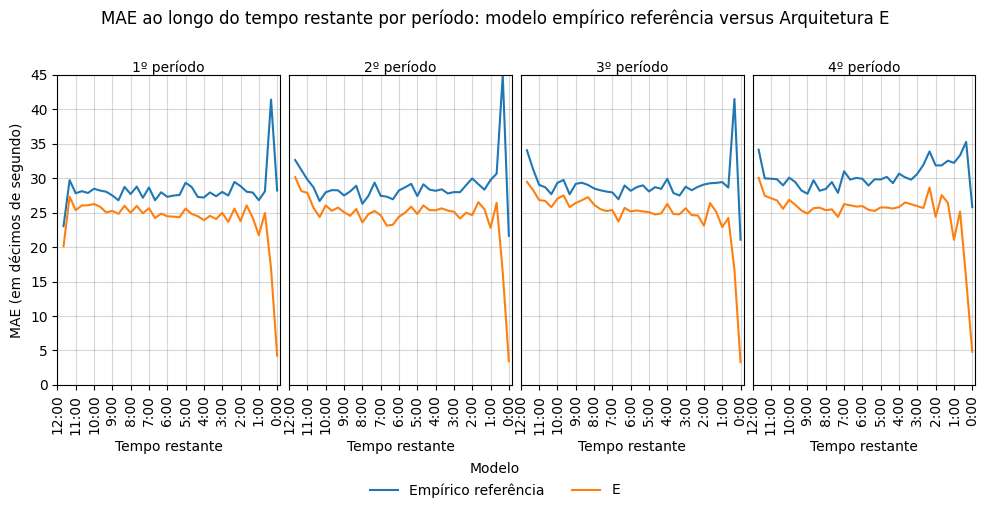

In [32]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultados3_agregado_melhores_modelos_TIME\
    .query("period == (@i + 1)")\
    .query("modelo == 'trigrama'")\
    .assign(modelo = "Empírico referência")\
    .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    .plot(ax = ax[i], legend = False)

    df_resultados3_agregado_melhores_modelos_TIME\
    .query("period == (@i + 1)")\
    .query("modelo == 'E'")\
    .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 45]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE (em décimos de segundo)")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("MAE ao longo do tempo restante por período: modelo empírico referência versus Arquitetura E", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [313]:
df_resultados3_agregado_melhores_modelos_TIME

,period,t1,mae,modelo,context_size,embedding_layer_size,set_covariables,num_hidden_neurons,num_layers,dropout_rate,layer_norm,bss_mean,mae_mean
144,1,700.0,23.031696,trigrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.304019,23.031696
145,1,680.0,29.725854,trigrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075139,29.725854
146,1,660.0,27.817545,trigrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.082208,27.817545
147,1,640.0,28.122582,trigrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075854,28.122582
148,1,620.0,27.862345,trigrama,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.078264,27.862345
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,4,640.0,NaN,E,5.0,32.0,56.0,50.0,5.0,0.0,True,0.117849,26.787134
140,4,660.0,NaN,E,5.0,32.0,56.0,50.0,5.0,0.0,True,0.111623,27.109312
141,4,680.0,NaN,E,5.0,32.0,56.0,50.0,5.0,0.0,True,0.099263,27.464707
142,4,700.0,NaN,E,5.0,32.0,56.0,50.0,5.0,0.0,True,0.072990,30.066507


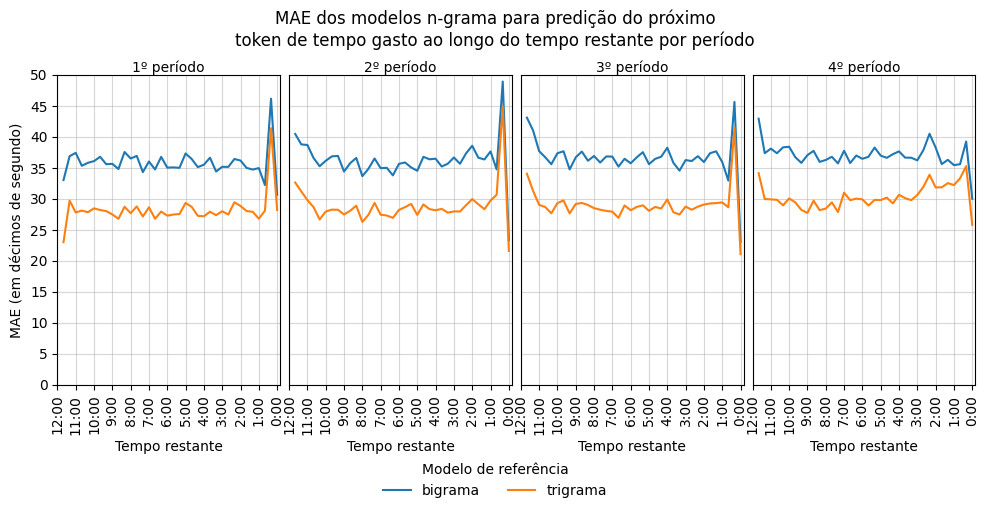

In [314]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

ordem_modelos = ["bigrama", "trigrama"]
for i in range(4):
    df_resultados_modelos_ref_TIME_SIZE\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "mae")\
    .reindex(columns = ordem_modelos)\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 50]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE (em décimos de segundo)")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
#fig.suptitle("Entropia cruzada ao longo do tempo restante por período", fontsize = 15, y = 0.98)
fig.suptitle("MAE dos modelos n-grama para predição do próximo\ntoken de tempo gasto ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

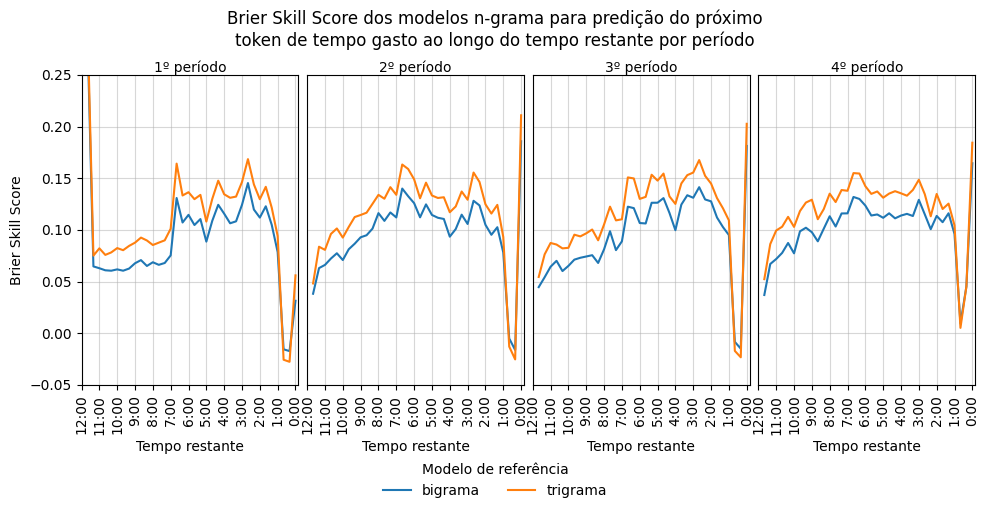

In [315]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):
    df_resultados_modelos_ref_TIME_SIZE\
    .query("period == (@i + 1)")\
    .pivot_table(index = "t1", columns = "modelo", values = "bss")\
    .plot(ax = ax[i], legend = False)

    bounds_y = [-0.05, 0.25]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score dos modelos n-grama para predição do próximo\ntoken de tempo gasto ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Modelo de referência", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [316]:
df_bss_comparison_time = pd.concat([
    
    df_resultados4_arquitetura_b_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_b_fn_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B (fine-tuning)")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_c_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "C")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_d_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "D")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],

    df_resultados4_arquitetura_e_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "E")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "bss_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
[["arquitetura", "period", "cat_time", "t1", "bss_mean"]]\
.pivot_table(index = ["period", "cat_time", "t1"], columns = "arquitetura", values = "bss_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.merge(df_resultados_modelos_ref_TIME_SIZE.pivot_table(index = ["period", "t1"], columns = "modelo", values = "bss").reset_index(), how = "left")


    

In [317]:
df_ce_comparison_time = pd.concat([
    
    df_resultados4_arquitetura_b_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_b_fn_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B (fine-tuning)")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_c_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "C")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_d_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "D")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],

    df_resultados4_arquitetura_e_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "E")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "cross_entropy_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
[["arquitetura", "period", "cat_time", "t1", "cross_entropy_mean"]]\
.pivot_table(index = ["period", "cat_time", "t1"], columns = "arquitetura", values = "cross_entropy_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.merge(df_resultados_modelos_ref_TIME_SIZE.pivot_table(index = ["period", "t1"], columns = "modelo", values = "cross_entropy").reset_index(), how = "left")


    

In [318]:
df_mae_comparison_time = pd.concat([
    
    df_resultados4_arquitetura_b_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "mae_mean"]],

    df_resultados4_arquitetura_b_fn_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "B (fine-tuning)")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "mae_mean"]],

    df_resultados4_arquitetura_c_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 2")\
    .assign(arquitetura = "C")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "mae_mean"]],

    df_resultados4_arquitetura_d_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "D")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "mae_mean"]],

    df_resultados4_arquitetura_e_TIME\
    .query("period <= 4")\
    .query("context_size == 5 & embedding_layer_size == 32 & num_hidden_neurons == 50 & num_layers == 5 & layer_norm == 0 & dropout_rate == 0 & set_covariables == 56")\
    .assign(arquitetura = "E")\
    [["arquitetura", "context_size", "embedding_layer_size", "num_hidden_neurons", "num_layers", "dropout_rate", "layer_norm", "set_covariables", "period", "cat_time", "mae_mean"]],
], axis = 0)\
.assign(t1 = lambda df: df["cat_time"].str.split("-").str[0].astype("int")/10)\
[["arquitetura", "period", "cat_time", "t1", "mae_mean"]]\
.pivot_table(index = ["period", "cat_time", "t1"], columns = "arquitetura", values = "mae_mean")\
.reset_index()\
.sort_values(["period", "t1"], ascending = [True, False])\
.merge(df_resultados_modelos_ref_TIME_SIZE.pivot_table(index = ["period", "t1"], columns = "modelo", values = "mae").reset_index(), how = "left")


    

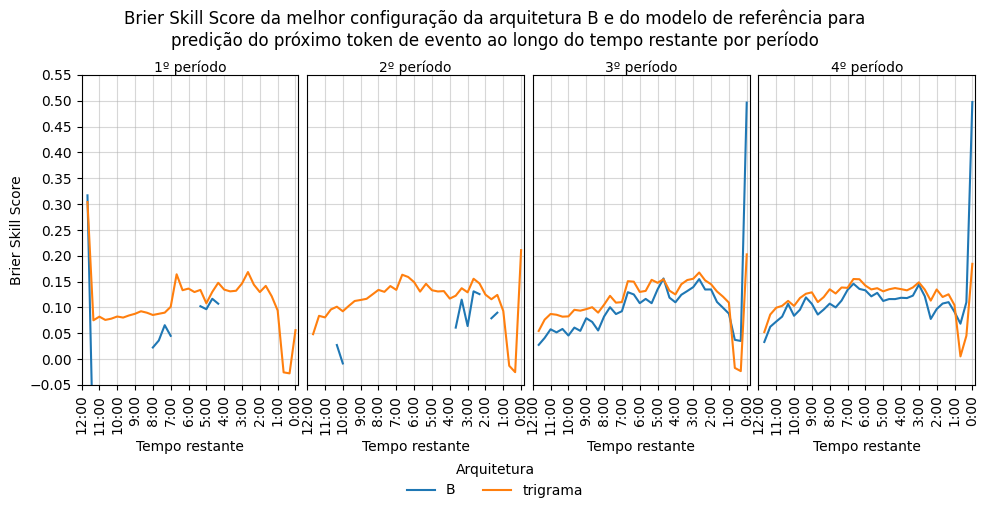

In [319]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_bss_comparison_time\
    .query("period == (@i + 1)")\
    .set_index("t1")\
    [["B", "trigrama"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [-0.05, 0.55]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.05))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Brier Skill Score da melhor configuração da arquitetura B e do modelo de referência para\npredição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Arquitetura", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

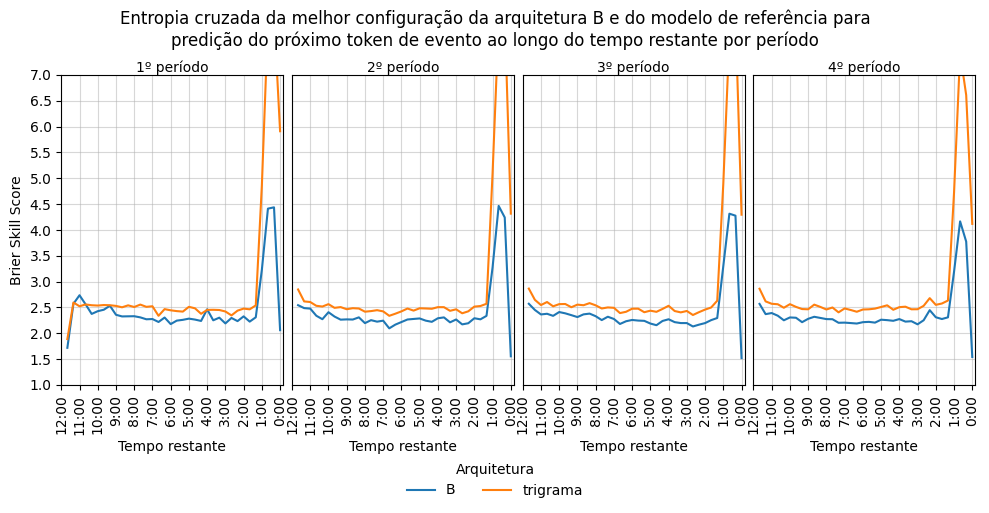

In [320]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_ce_comparison_time\
    .query("period == (@i + 1)")\
    .set_index("t1")\
    [["B", "trigrama"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [1.0, 7]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 0.5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Brier Skill Score")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Entropia cruzada da melhor configuração da arquitetura B e do modelo de referência para\npredição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Arquitetura", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

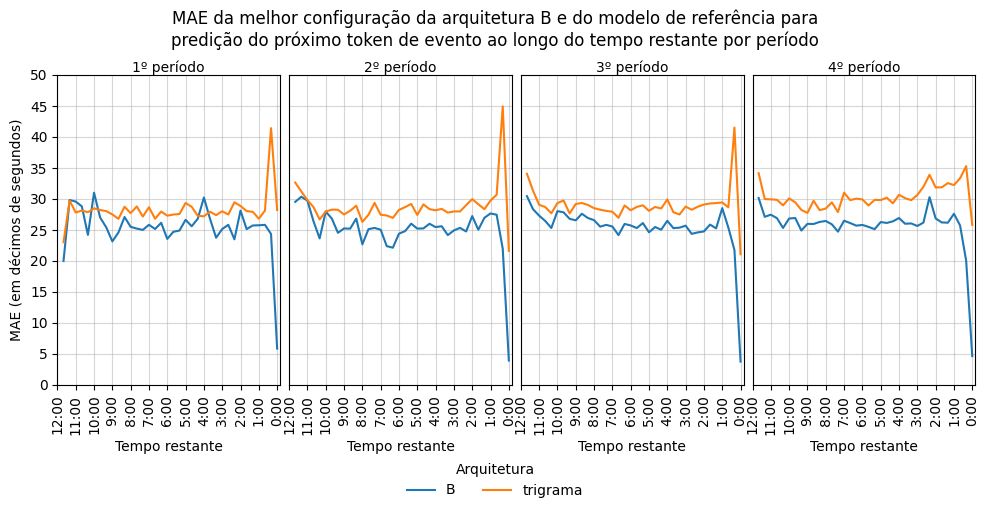

In [321]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_mae_comparison_time\
    .query("period == (@i + 1)")\
    .set_index("t1")\
    [["B", "trigrama"]]\
    .plot(ax = ax[i], legend = False)

    bounds_y = [0, 50]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0], bounds_y[1] + 0.01, 5))
    ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("MAE (em décimos de segundos)")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("MAE da melhor configuração da arquitetura B e do modelo de referência para\npredição do próximo token de evento ao longo do tempo restante por período", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, title = "Arquitetura", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [322]:
df_bss_comparison_time\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])\
.assign(best_ngram = lambda df: df[["bigrama", "trigrama"]].max(axis = 1))\
.assign(best_ngram = lambda df: np.where(df["best_ngram"] <= 0.001, 0.001, df["best_ngram"]))\
.assign(ratio_b = lambda df: df["B"] / df["best_ngram"])\
.assign(ratio_b_fn = lambda df: df["B (fine-tuning)"] / df["best_ngram"])\
.assign(ratio_c = lambda df: df["C"] / df["best_ngram"])\
.assign(ratio_d = lambda df: df["D"] / df["best_ngram"])\
.assign(ratio_e = lambda df: df["E"] / df["best_ngram"])\
[["ratio_b", "ratio_b_fn", "ratio_c", "ratio_d", "ratio_e"]].describe()

C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\lib\_function_base_impl.py:4653: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
C:\Users\User\AppData\Roaming\Python\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
c:\Users\User\anaconda3\envs\jupyter_simple\Lib\site-packages\numpy\li

,ratio_b,ratio_b_fn,ratio_c,ratio_d,ratio_e
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,-inf,-inf,-inf,-inf,-inf
std,NaN,NaN,NaN,NaN,NaN
min,-inf,-inf,-inf,-inf,-inf
25%,NaN,NaN,NaN,NaN,NaN
50%,0.720818,0.720818,0.721629,0.721381,0.718553
75%,0.875081,0.875081,0.871556,0.871610,0.865131
max,37.340809,37.340809,36.207240,36.388437,35.553745


In [323]:
df_ce_comparison_time\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])\
.assign(best_ngram = lambda df: df[["bigrama", "trigrama"]].min(axis = 1))\
.assign(ratio_b = lambda df: 1 - (df["B"] / df["best_ngram"]))\
.assign(ratio_b_fn = lambda df: 1 - (df["B (fine-tuning)"] / df["best_ngram"]))\
.assign(ratio_c = lambda df: 1 - (df["C"] / df["best_ngram"]))\
.assign(ratio_d = lambda df: 1 - (df["D"] / df["best_ngram"]))\
.assign(ratio_e = lambda df: 1 - (df["E"] / df["best_ngram"]))\
[["ratio_b", "ratio_b_fn", "ratio_c", "ratio_d", "ratio_e"]].describe()

,ratio_b,ratio_b_fn,ratio_c,ratio_d,ratio_e
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,0.118536,0.118536,0.118589,0.120900,0.118834
std,0.114568,0.114568,0.116457,0.117650,0.116103
min,-0.084361,-0.084361,-0.085368,-0.066700,-0.101730
25%,0.074680,0.074680,0.073408,0.074731,0.074510
50%,0.090590,0.090590,0.089410,0.090298,0.088905
75%,0.102185,0.102185,0.101897,0.102923,0.099935
max,0.621911,0.621911,0.630821,0.633018,0.634548


In [324]:
df_mae_comparison_time\
.set_index(["period", "t1"])\
.drop(columns = ["cat_time"])\
.assign(best_ngram = lambda df: df[["bigrama", "trigrama"]].min(axis = 1))\
.assign(ratio_b = lambda df: 1 - (df["B"] / df["best_ngram"]))\
.assign(ratio_b_fn = lambda df: 1 - (df["B (fine-tuning)"] / df["best_ngram"]))\
.assign(ratio_c = lambda df: 1 - (df["C"] / df["best_ngram"]))\
.assign(ratio_d = lambda df: 1 - (df["D"] / df["best_ngram"]))\
.assign(ratio_e = lambda df: 1 - (df["E"] / df["best_ngram"]))\
[["ratio_b", "ratio_b_fn", "ratio_c", "ratio_d", "ratio_e"]].describe()

,ratio_b,ratio_b_fn,ratio_c,ratio_d,ratio_e
count,144.000000,144.000000,144.000000,144.000000,144.000000
mean,0.127192,0.127192,0.129826,0.136579,0.129032
std,0.139539,0.139539,0.145309,0.152419,0.141934
min,-0.111417,-0.111417,-0.142191,-0.101210,-0.097588
25%,0.079563,0.079563,0.077217,0.080182,0.079073
50%,0.103256,0.103256,0.104673,0.108179,0.106120
75%,0.133515,0.133515,0.130223,0.133577,0.131280
max,0.821588,0.821588,0.839000,0.846622,0.836881


### Testes próximo token de evento

In [138]:
import os
import math
import pandas as pd
import numpy as np
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pickle
import tqdm
%matplotlib inline
from IPython.display import clear_output
from typing import List, Tuple, Optional
import matplotlib.ticker as mticker

os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

# data_folder = "drive/MyDrive/mestrado_final_files/data/"
# models_token_folder = "drive/MyDrive/mestrado_final_files/models/NGramModel_ExtraInfo_TimeDiffTower/"
# models_token_metrics_folder = "drive/MyDrive/mestrado_final_files/metrics_models/NGramModel_ExtraInfo_TimeDiffTower/"

data_folder = "G:\Meu Drive\mestrado_final_files\data\\"
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo_TimeDiffTower\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_TimeDiffTower\\"

#models_time_folder = "G:\Meu Drive\mestrado_final_files\models\\SpentTimeModel\\"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [139]:
tokens_info = pd.read_csv(data_folder + 'tokens_info.txt', sep = ';')\
.sort_values(['cod', 'token'])\
.set_index('token')

# Convert the index of tokens_info to a list of tokens
list_tokens = tokens_info.index.to_list()

# Create a dictionary mapping each token to a unique integer, starting from 1
token_to_integer = {tok: idx + 1 for idx, tok in enumerate(list_tokens)}

# Assign a special integer (0) for the period (.)
token_to_integer['.'] = 0

# Create an inverse mapping from integers back to tokens
integer_to_token = {idx: tok for tok, idx in token_to_integer.items()}


In [140]:
[integer_to_token[i] for i in [62, 63, 456, 586, 192]]

['p440_1(5a)',
 'p550_1(5a)',
 'p451_6(11p)p500_3(12w)p300_4(1t)',
 'p200_9(0)p440_8(0)p440_8(0)p440_8(0)',
 'p500_3(22c)']

In [141]:
%run 01_functions_training.ipynb

In [327]:
# with open(data_folder + 'data_token_features.pkl', 'rb') as f:
#     df_token_features = pickle.load(f)

In [142]:
with open(data_folder + 'dict_set_covariables.pkl', 'rb') as f:
    dict_set_covariables = pickle.load(f)

In [143]:
models_token_folder = "G:\Meu Drive\mestrado_final_files\models\\NGramModel_ExtraInfo_TimeDiffTower\\"
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_TimeDiffTower\\"
data_folder = "G:\Meu Drive\mestrado_final_files\data\\"

In [144]:
list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_TimeDiffTower" in item and ".pth" in item]

In [331]:
# df_contagens_tokens = df_token_features\
# .assign(tk = lambda df: df["token_features"].str[-5:])\
# ["tk"].value_counts()

In [240]:
list_secs = 4 * [i/720 for i in range(0, 721)]

period1_list = 721 * [1] + 3*721 * [0]
period2_list = 721 * [0] + 721 * [1] + 2*721 * [0]
period3_list = 2*721 * [0] + 721 * [1] + 721 * [0]
period4_list = 3*721 * [0] + 721 * [1]
period5_list = 4*721 * [0]
dif_list = 4*721*[5/20]
bp_list = 4*721*[1]
away_leading_list = 4*721*[0]
home_leading_list = 4*721*[1]
t1200_list = 4*[1 if i <= 120 and i > 60 else 0 for i in range(0, 721)]
t600_list = 4*[1 if i <= 60  and i > 20 else 0 for i in range(0, 721)]
t200_list = 4*[1 if i <= 20  and i > 10 else 0 for i in range(0, 721)]
t100_list = 4*[1 if i <= 10  and i > 5 else 0 for i in range(0, 721)]
t50_list = 4*[1 if i <= 5  and i > 1 else 0 for i in range(0, 721)]
t10_list = 4*[1 if i <= 1 else 0 for i in range(0, 721)]
indclose3_list = 4*721*[0]
indclose5_list = 4*721*[1]
indclose8_list = 4*721*[1]
indblowout15_list = 4*721*[0]
timeout_home_list = 4*721*[0]
timeout_away_list = 4*721*[0]

entrada_jogo_equilibrado_torre = [period1_list, period2_list, period3_list, period4_list, period5_list, list_secs, dif_list] 
entrada_jogo_equilibrado_outra = [timeout_home_list, timeout_away_list, indclose3_list, indclose5_list, indclose8_list, 
                                  indblowout15_list, t1200_list, t600_list, t200_list, t100_list, t50_list, t10_list, 
                                  home_leading_list, away_leading_list, bp_list]



In [227]:
[integer_to_token[i] for i in [145, 239, 144, 240, 63]]

['p500_2(5)', 'p400_4(0p)', 'p400_2(5)', 'p500_4(0p)', 'p550_1(5a)']

In [241]:
vetor_tokens = torch.tensor(np.asarray(4*721*[[145, 239, 144, 240, 63]]), dtype = torch.int64)

In [242]:
vetor_torre = torch.tensor(np.asarray(entrada_jogo_equilibrado_torre).T, dtype = torch.float32)
vetor_outra = torch.tensor(np.asarray(entrada_jogo_equilibrado_outra).T, dtype = torch.float32)

In [243]:
np.array(entrada_jogo_equilibrado_torre).T.shape
np.array(entrada_jogo_equilibrado_outra).T.shape

(2884, 15)

In [244]:
fouls = 0
df_ref = pd.DataFrame({"period": [1, 2, 3, 4], "limhfouls": [fouls, fouls, fouls, fouls], "limvfouls": [fouls, fouls, fouls, fouls]})

ref_mask = build_logit_mask_ngram_models(df_ref)

entrada_mascara = np.vstack([
    np.tile(ref_mask[0], (721, 1)),
    np.tile(ref_mask[1], (721, 1)),
    np.tile(ref_mask[2], (721, 1)),
    np.tile(ref_mask[3], (721, 1))
])

vetor_mascara = torch.tensor(entrada_mascara, dtype = torch.bool)


In [245]:
vetor_tokens.shape, vetor_torre.shape, vetor_outra.shape, vetor_mascara.shape

(torch.Size([2884, 5]),
 torch.Size([2884, 7]),
 torch.Size([2884, 15]),
 torch.Size([2884, 601]))

In [233]:
VOCAB_SIZE = 601

In [234]:
lista_qualquer_arremesso_certo_2pts = [j for i, j in token_to_integer.items() if "p4" in i and "_1(" in i and "(5" not in i]
lista_qualquer_arremesso_errado_2pts = [j for i, j in token_to_integer.items() if "p4" in i and "_2(" in i and "(5" not in i]
lista_qualquer_arremesso_certo_3pts = [j for i, j in token_to_integer.items() if "p4" in i and "_1(5" in i]
lista_qualquer_arremesso_errado_3pts = [j for i, j in token_to_integer.items() if "p4" in i and "_2(5" in i]
lista_qualquer_turnover = [j for i, j in token_to_integer.items() if "p4" in i and "_5(" in i]
lista_qualquer_falta = [j for i, j in token_to_integer.items() if "p5" in i and "_6(" in i]
lista_final_jogo = [j for i, j in token_to_integer.items() if "_13(" in i]
lista_substituicao = [j for i, j in token_to_integer.items() if "_8(" in i]

In [246]:
lista_resultados = []
#    model_filename = [item for item in list_models if "embedding32" in item and "numlayers3" in item and "nodropout" in item and "layernormFalse" in item][0]

for model_filename in [item for item in list_models if "embedding32" in item and "numlayers3" in item and "nodropout" in item and "layernormFalse" in item]:

    CONTEXT_SIZE = int(model_filename.split("_context")[1].split("_")[0])
    EMBEDDING_LAYER_SIZE = int(model_filename.split("_embedding")[1].split("_")[0])
    variables_config = int(model_filename.split("_setcovariables")[1].split("_")[0])
    num_hidden_neurons = int(model_filename.split("_numneurons")[1].split("_")[0])
    num_layers = int(model_filename.split("_numlayers")[1].split("_")[0])
    dropout_rate = 0 if "nodropout" in model_filename else int(model_filename.split("_dropout")[1].split("_")[0]) / 10
    layer_norm = True if model_filename.split("_layernorm")[1].split("_")[0] == 'True' else False

    index_num_covariables = dict_set_covariables["index"][5]
    num_covariables = dict_set_covariables["covariables"][5]

    index_tower_covariables = dict_set_covariables["index"][6]
    tower_covariables = dict_set_covariables["covariables"][6]

    token_model = NGramModel_ExtraInfo_TimeDiffTower(context_size = CONTEXT_SIZE, vocab_size = VOCAB_SIZE,
                                                        embedding_dim = EMBEDDING_LAYER_SIZE, numerical_input_dim = len(index_num_covariables),
                                                        time_diff_input_dim = len(index_tower_covariables), time_tower_hidden_dim = 16,
                                                        time_tower_out_dim = 16, num_hidden_neurons = num_hidden_neurons, num_layers = num_layers,
                                                        activation = nn.GELU, dropout_rate = dropout_rate, use_layer_norm = layer_norm)

    token_model.load_state_dict(torch.load(models_token_folder + model_filename, weights_only = True, map_location = torch.device('cpu')))
    token_model.eval()

    output = token_model(vetor_tokens, vetor_torre, vetor_outra)
    output = output.masked_fill(vetor_mascara, -1e9)
    output[:, 0] = -float("inf")
    probabilities = torch.softmax(output, dim = 1)

    probs_arremesso_certo_2pts = probabilities[:, lista_qualquer_arremesso_certo_2pts].sum(dim = 1).detach().cpu().numpy()
    probs_arremesso_errado_2pts = probabilities[:, lista_qualquer_arremesso_errado_2pts].sum(dim = 1).detach().cpu().numpy()
    probs_arremesso_certo_3pts = probabilities[:, lista_qualquer_arremesso_certo_3pts].sum(dim = 1).detach().cpu().numpy()
    probs_arremesso_errado_3pts = probabilities[:, lista_qualquer_arremesso_errado_3pts].sum(dim = 1).detach().cpu().numpy()    
    probs_turnover = probabilities[:, lista_qualquer_turnover].sum(dim = 1).detach().cpu().numpy()    
    probs_falta = probabilities[:, lista_qualquer_falta].sum(dim = 1).detach().cpu().numpy()   
    probs_final_jogo = probabilities[:, lista_final_jogo].sum(dim = 1).detach().cpu().numpy()   
    lista_substituicao = probabilities[:, lista_substituicao].sum(dim = 1).detach().cpu().numpy()   

    df_teste = pd.DataFrame({
    "periodo": 721 * [1] + 721 * [2] + 721 * [3] + 721 * [4],
    "remaining_time": [i * 720 for i in list_secs],
    "prob2pts_certo": probs_arremesso_certo_2pts,
    "prob2pts_errado": probs_arremesso_errado_2pts,
    "prob3pts_certo": probs_arremesso_certo_3pts,
    "prob3pts_errado": probs_arremesso_errado_3pts,
    "prob_turnover": probs_turnover,
    "prob_falta": probs_falta,
    "prob_final_jogo": probs_final_jogo,
    "prob_substituicao": lista_substituicao,
    })
    
    lista_resultados.append(df_teste)

In [247]:
df_resultado_medio = pd.concat(lista_resultados)\
.groupby(["periodo", "remaining_time"], as_index = False, dropna = False)\
[["prob2pts_certo", "prob2pts_errado", "prob3pts_certo", "prob3pts_errado", "prob_turnover", "prob_falta", "prob_final_jogo", "prob_substituicao"]].mean()

In [248]:
df_resultado_medio1.head()

,periodo,remaining_time,prob2pts_certo,prob2pts_errado,prob3pts_certo,prob3pts_errado,prob_turnover,prob_falta,prob_final_jogo,prob_substituicao
0,1,0.0,0.180431,0.171279,0.073377,0.137176,0.101811,0.182736,0.081260,0.003283
1,1,1.0,0.180263,0.171138,0.073306,0.137132,0.101785,0.182767,0.081587,0.003328
2,1,2.0,0.227872,0.197437,0.098581,0.172116,0.122152,0.167092,0.012885,0.002325
3,1,3.0,0.227749,0.197366,0.098518,0.172114,0.122152,0.167284,0.012982,0.002347
4,1,4.0,0.227626,0.197294,0.098455,0.172112,0.122152,0.167477,0.013079,0.002369


In [249]:
df_resultado_medio

,periodo,remaining_time,prob2pts_certo,prob2pts_errado,prob3pts_certo,prob3pts_errado,prob_turnover,prob_falta,prob_final_jogo,prob_substituicao
0,1,0.0,0.178167,0.173691,0.072866,0.129738,0.108808,0.183392,0.095944,0.0
1,1,1.0,0.178015,0.173510,0.072810,0.129707,0.108780,0.183409,0.096297,0.0
2,1,2.0,0.224486,0.199713,0.097611,0.166783,0.131078,0.166101,0.013760,0.0
3,1,3.0,0.224376,0.199623,0.097560,0.166766,0.131078,0.166297,0.013871,0.0
4,1,4.0,0.224265,0.199533,0.097508,0.166747,0.131077,0.166494,0.013982,0.0
...,...,...,...,...,...,...,...,...,...,...
2879,4,716.0,0.139891,0.125040,0.057006,0.101732,0.092626,0.201727,0.001673,0.0
2880,4,717.0,0.139643,0.124800,0.056876,0.101512,0.092475,0.201634,0.001678,0.0
2881,4,718.0,0.139394,0.124559,0.056746,0.101291,0.092323,0.201540,0.001683,0.0
2882,4,719.0,0.139145,0.124317,0.056616,0.101070,0.092171,0.201445,0.001688,0.0


In [269]:
50*300

15000

In [277]:
70469-55169

15300

In [271]:
70133-54833

15300

In [272]:
64983-49683

15300

In [261]:
df_resultado_medio.query("remaining_time >= 660 & remaining_time % 10 == 0 & periodo == 4")

,periodo,remaining_time,prob2pts_certo,prob2pts_errado,prob3pts_certo,prob3pts_errado,prob_turnover,prob_falta,prob_final_jogo,prob_substituicao
2823,4,660.0,0.152571,0.137103,0.063881,0.113012,0.099905,0.205007,0.001376,0.0
2833,4,670.0,0.150512,0.135188,0.062737,0.111198,0.098800,0.204711,0.001432,0.0
2843,4,680.0,0.148355,0.133158,0.061549,0.109281,0.097603,0.204289,0.001487,0.0
2853,4,690.0,0.146107,0.131021,0.060322,0.107275,0.096320,0.203738,0.001541,0.0
2863,4,700.0,0.143775,0.128787,0.059065,0.105191,0.094956,0.203061,0.001594,0.0
2873,4,710.0,0.141368,0.126468,0.057784,0.103044,0.093520,0.202261,0.001644,0.0
2883,4,720.0,0.138894,0.124075,0.056485,0.100849,0.092018,0.201349,0.001693,0.0


In [262]:
df_resultado_medio1.query("remaining_time >= 660 & remaining_time % 10 == 0 & periodo == 4")

,periodo,remaining_time,prob2pts_certo,prob2pts_errado,prob3pts_certo,prob3pts_errado,prob_turnover,prob_falta,prob_final_jogo,prob_substituicao
2823,4,660.0,0.147734,0.133262,0.068543,0.127194,0.079115,0.179755,0.000427,0.049344
2833,4,670.0,0.145423,0.131352,0.067663,0.125941,0.077861,0.177980,0.000435,0.048909
2843,4,680.0,0.142963,0.129256,0.066693,0.124515,0.076542,0.176068,0.000444,0.048514
2853,4,690.0,0.140364,0.126981,0.065634,0.122918,0.075159,0.174013,0.000453,0.048158
2863,4,700.0,0.137636,0.124538,0.064490,0.121158,0.073716,0.171813,0.000463,0.047840
2873,4,710.0,0.134796,0.121942,0.063267,0.119241,0.072216,0.169467,0.000472,0.047558
2883,4,720.0,0.131858,0.119210,0.061972,0.117181,0.070666,0.166978,0.000481,0.047311


In [264]:
0.066693/0.061549

1.0835756876634877

In [263]:
0.124515/0.109281

1.1394020918549428

In [265]:
(0.066693 + 0.124515) / (0.061549 + 0.109281)

1.1192881812328044

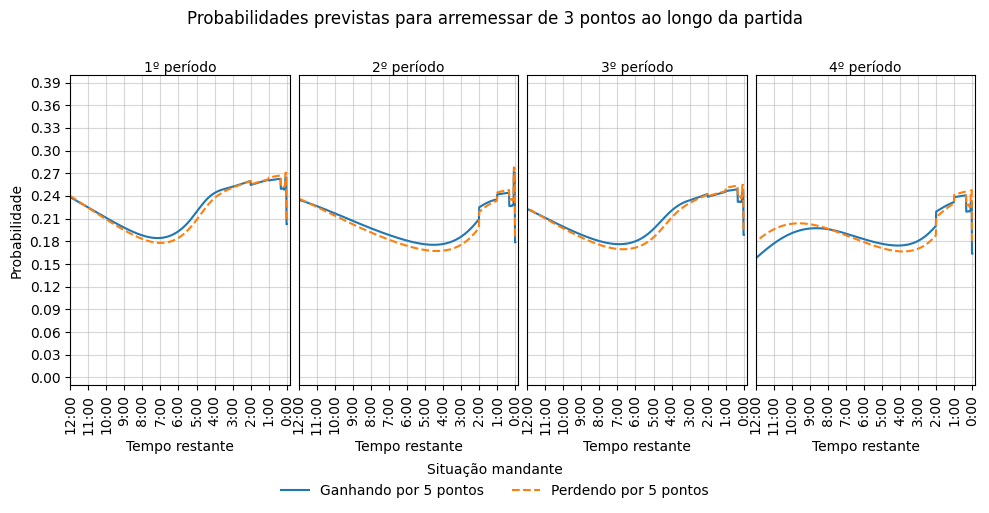

In [250]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    .assign(prob3pts = lambda df: df["prob3pts_certo"] + df["prob3pts_errado"])\
    [["prob3pts"]]\
    .plot(ax = ax[i], legend = False)

    df_resultado_medio1\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    .assign(prob3pts = lambda df: df["prob3pts_certo"] + df["prob3pts_errado"])\
    [["prob3pts"]]\
    .plot(ax = ax[i], legend = False, linestyle = "--")

    bounds_y = [-0.01, 0.4]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para arremessar de 3 pontos ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Ganhando por 5 pontos", "Perdendo por 5 pontos"]
fig.legend(handles, labels, title = "Situação mandante", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

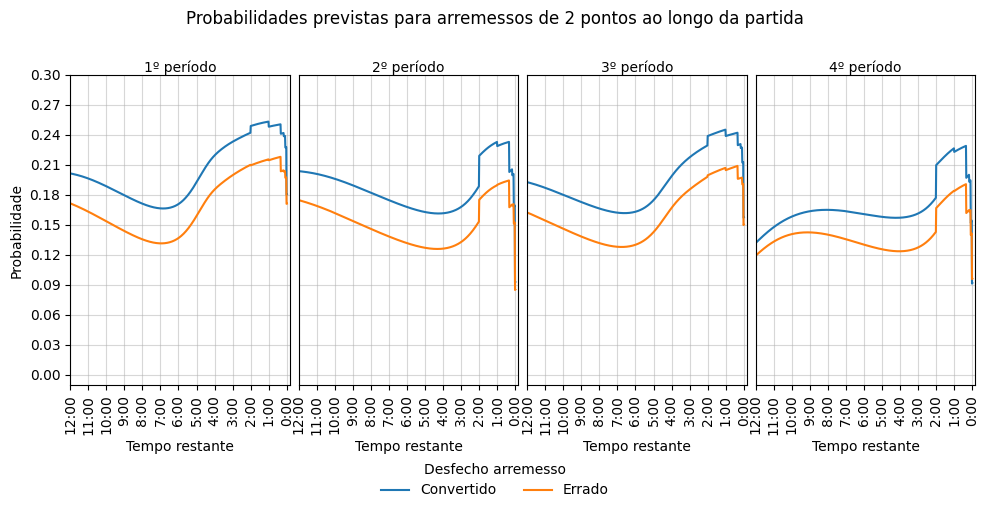

In [157]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob2pts_certo", "prob2pts_errado"]]\
    .plot(ax = ax[i], legend = False)

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.3]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para arremessos de 2 pontos ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Convertido", "Errado"]
fig.legend(handles, labels, title = "Desfecho arremesso", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [510]:
labels

['prob2pts_certo', 'prob2pts_errado']

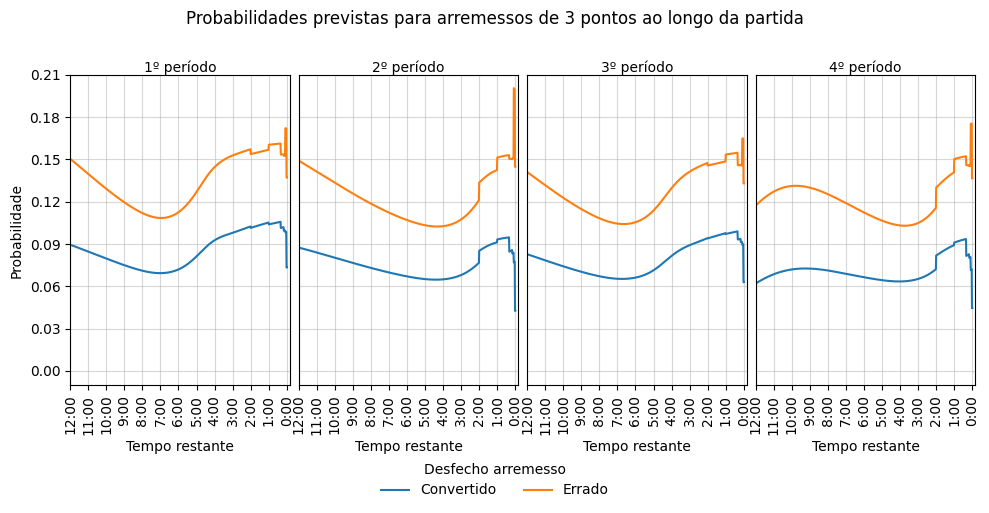

In [515]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob3pts_certo", "prob3pts_errado"]]\
    .plot(ax = ax[i], legend = False)

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.21]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para arremessos de 3 pontos ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Convertido", "Errado"]
fig.legend(handles, labels, title = "Desfecho arremesso", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

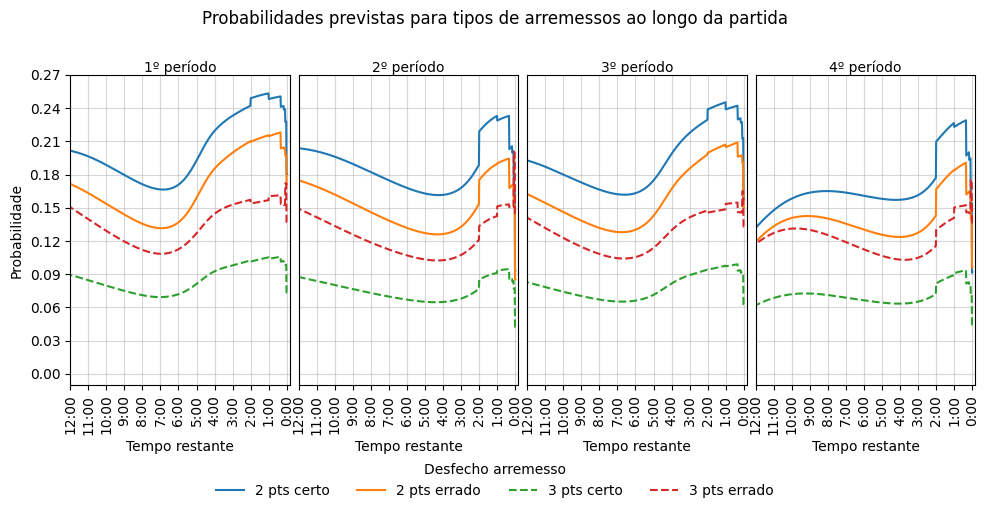

In [533]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):
    estilos_de_linha = ["-", "-", ":", ":"]
    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob2pts_certo", "prob2pts_errado"]]\
    .plot(ax = ax[i], legend = False)

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob3pts_certo", "prob3pts_errado"]]\
    .plot(ax = ax[i], legend = False, linestyle = "--")

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.27]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para tipos de arremessos ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["2 pts certo", "2 pts errado", "3 pts certo", "3 pts errado" ]
fig.legend(handles, labels, title = "Desfecho arremesso", loc = "lower center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

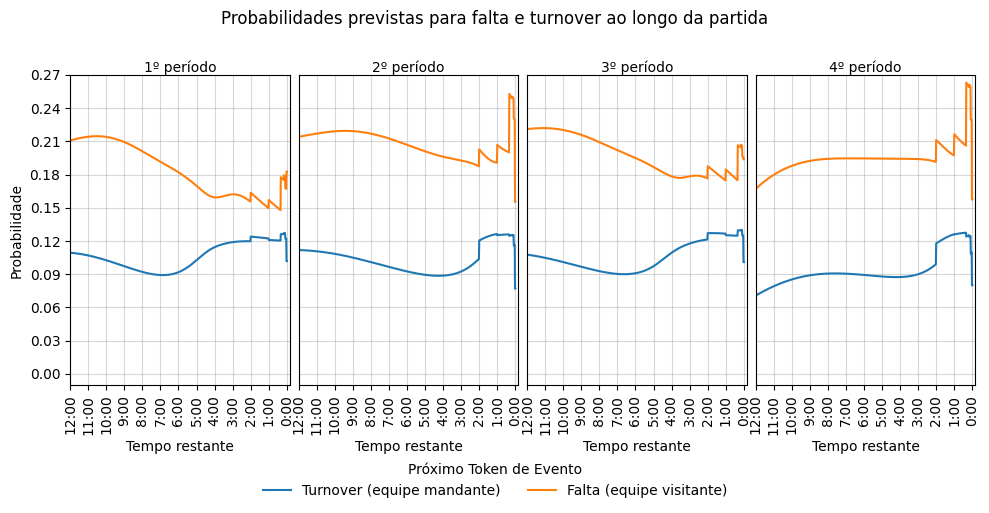

In [519]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob_turnover", "prob_falta"]]\
    .plot(ax = ax[i], legend = False)

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.27]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para falta e turnover ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Turnover (equipe mandante)", "Falta (equipe visitante)"]
fig.legend(handles, labels, title = "Próximo Token de Evento", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

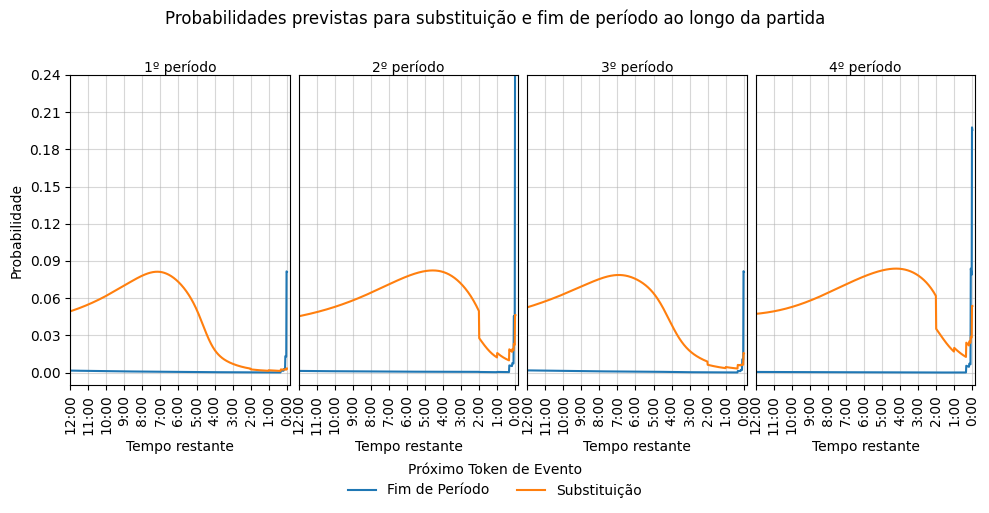

In [522]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["prob_final_jogo", "prob_substituicao"]]\
    .plot(ax = ax[i], legend = False)

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.24]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.03))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Probabilidade")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

# título geral
fig.suptitle("Probabilidades previstas para substituição e fim de período ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["Fim de Período", "Substituição"]
fig.legend(handles, labels, title = "Próximo Token de Evento", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

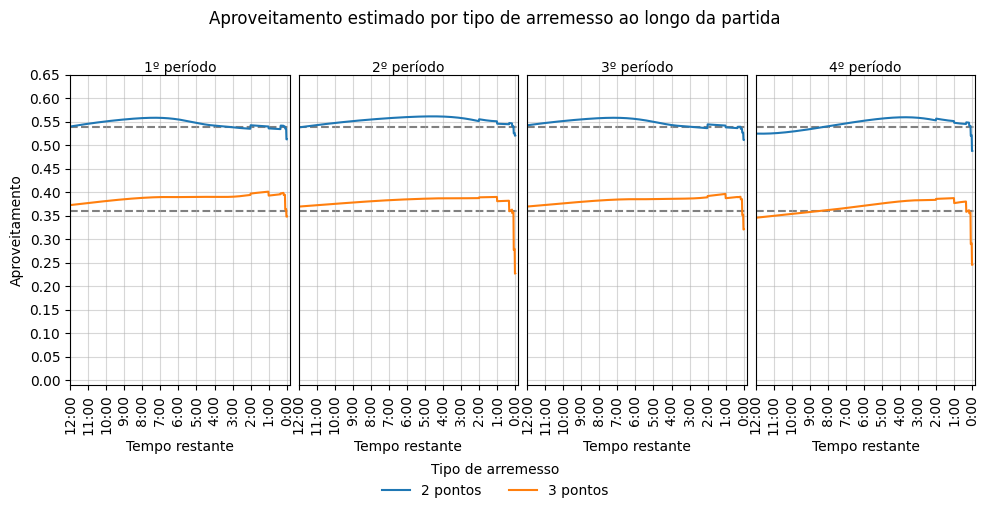

In [524]:
fig, ax = plt.subplots(1, 4, figsize = (10, 5))

for i in range(4):

    df_resultado_medio\
    .assign(apr_2pts = lambda df: df["prob2pts_certo"] / (df["prob2pts_certo"] + df["prob2pts_errado"]))\
    .assign(apr_3pts = lambda df: df["prob3pts_certo"] / (df["prob3pts_certo"] + df["prob3pts_errado"]))\
    .query("periodo == (@i + 1)")\
    .set_index("remaining_time")\
    [["apr_2pts", "apr_3pts"]]\
    .plot(ax = ax[i], legend = False)

    # df_resultados3_agregado_melhores_modelos_TIME\
    # .query("period == (@i + 1)")\
    # .query("modelo == 'E'")\
    # .pivot_table(index = "t1", columns = "modelo", values = "mae_mean")\
    # .plot(ax = ax[i], legend = False)

    bounds_y = [-0.01, 0.65]
    ax[i].set_ylim(bounds_y)
    ax[i].set_yticks(np.arange(bounds_y[0] + 0.01, bounds_y[1] + 0.01, 0.05))
    # ax[i].invert_xaxis()
    ax[i].set_xlim(720, -10)
    ax[i].set_xticks([720, 660, 600, 540, 480, 420, 360, 300, 240, 180, 120, 60, 0])
    ax[i].xaxis.set_major_formatter(mticker.FuncFormatter(format_time_seconds))
    ax[i].tick_params(axis = "x", labelrotation = 90)

    ax[i].grid(True, alpha = 0.5)
    ax[i].set_title(f"{i+1}º período", fontsize = 10, pad = 2)
    ax[i].set_xlabel("Tempo restante")

    if i == 0:
        ax[i].set_ylabel("Aproveitamento")
        ax[i].tick_params(axis = "y", labelleft = True)
    else:
        ax[i].set_ylabel("")
        ax[i].tick_params(axis = "y", left = False, labelleft = False)

    ax[i].axhline(0.54, color = 'gray', linestyle = '--', zorder = -3)
    ax[i].axhline(0.36, color = 'gray', linestyle = '--', zorder = -3)
# título geral
fig.suptitle("Aproveitamento estimado por tipo de arremesso ao longo da partida", fontsize = 12, y = 0.95)

# legenda única embaixo
handles, labels = ax[0].get_legend_handles_labels()
labels = ["2 pontos", "3 pontos"]
fig.legend(handles, labels, title = "Tipo de arremesso", loc = "lower center", ncol = 3, frameon = False, bbox_to_anchor = (0.5, -0.05))

plt.tight_layout()
fig.subplots_adjust(wspace = 0.04, top = 0.82, bottom = 0.20)
plt.show()

In [534]:
models_token_folder

'G:\\Meu Drive\\mestrado_final_files\\models\\NGramModel_ExtraInfo_TimeDiffTower\\'

In [539]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir(models_token_folder) if "NGramModel_ExtraInfo_TimeDiffTower" in item and ".pkl" in item and str_season in item and "embedding32" in item and "numlayers3" in item and "nodropout" in item and "layernormFalse" in item]

    for file in tqdm.tqdm(list_models):
        with open(models_token_folder + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["variable_importance"]))

100%|██████████| 1/1 [00:00<00:00, 74.04it/s]


In [543]:
df_desempenho_modelos_ref_token_evento

,modelo,cross_entropy_mean,cross_entropy_std,bss_mean,bss_std
0,unigrama,4.394708,0.022779,-0.000028,0.000011
1,bigrama,3.101946,0.021676,0.156035,0.002448
2,trigrama,3.229164,0.026243,0.154825,0.002509


,feature,count,mean,std,min,25%,50%,75%,max,baseline,perc,percacm
4,token_1,10.0,9.2647,0.0351,11.9807,12.0206,12.0277,12.0486,12.1078,2.7707,91.6417,91.6417
3,token_2,10.0,0.4022,0.0051,3.1648,3.1691,3.1730,3.1772,3.1796,2.7707,3.9785,95.6202
10,time,10.0,0.0868,0.0024,2.8541,2.8559,2.8579,2.8587,2.8619,2.7707,0.8586,96.4788
2,token_3,10.0,0.0843,0.0015,2.8517,2.8546,2.8551,2.8561,2.8569,2.7707,0.8334,97.3122
23,ind_last_second,10.0,0.0660,0.0006,2.8358,2.8363,2.8367,2.8372,2.8377,2.7707,0.6528,97.9650
5,period1,10.0,0.0428,0.0015,2.8113,2.8121,2.8136,2.8147,2.8154,2.7707,0.4230,98.3880
7,period3,10.0,0.0297,0.0011,2.7982,2.8002,2.8004,2.8010,2.8019,2.7707,0.2937,98.6817
22,ind_last_5_seconds,10.0,0.0280,0.0005,2.7978,2.7986,2.7987,2.7990,2.7997,2.7707,0.2772,98.9590
26,ball_possession,10.0,0.0233,0.0012,2.7919,2.7934,2.7940,2.7950,2.7958,2.7707,0.2304,99.1894
1,token_4,10.0,0.0229,0.0008,2.7926,2.7929,2.7938,2.7943,2.7945,2.7707,0.2268,99.4162


In [561]:
#[4.425082, 4.388531, 4.378008, 4.368121, 4.388993]

lista_resultados_importancia = []

valor_ref = 4.425082 
df_importancia = list_num_parametros[0][1]\
.assign(mean = lambda df: np.where(df["mean"] > (valor_ref - df["baseline"]), (valor_ref - df["baseline"]), df["mean"]))\
.assign(imp_rel = lambda df: df["mean"] / (valor_ref - df["baseline"]))\
.assign(perc = lambda df: 100 * df["mean"] / df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() / df["mean"].sum())
lista_resultados_importancia.append(df_importancia)

valor_ref = 4.388531 
df_importancia = list_num_parametros[1][1]\
.assign(mean = lambda df: np.where(df["mean"] > (valor_ref - df["baseline"]), (valor_ref - df["baseline"]), df["mean"]))\
.assign(imp_rel = lambda df: df["mean"] / (valor_ref - df["baseline"]))\
.assign(perc = lambda df: 100 * df["mean"] / df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() / df["mean"].sum())
lista_resultados_importancia.append(df_importancia)

valor_ref = 4.378008 
df_importancia = list_num_parametros[2][1]\
.assign(mean = lambda df: np.where(df["mean"] > (valor_ref - df["baseline"]), (valor_ref - df["baseline"]), df["mean"]))\
.assign(imp_rel = lambda df: df["mean"] / (valor_ref - df["baseline"]))\
.assign(perc = lambda df: 100 * df["mean"] / df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() / df["mean"].sum())
lista_resultados_importancia.append(df_importancia)

valor_ref = 4.368121 
df_importancia = list_num_parametros[3][1]\
.assign(mean = lambda df: np.where(df["mean"] > (valor_ref - df["baseline"]), (valor_ref - df["baseline"]), df["mean"]))\
.assign(imp_rel = lambda df: df["mean"] / (valor_ref - df["baseline"]))\
.assign(perc = lambda df: 100 * df["mean"] / df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() / df["mean"].sum())
lista_resultados_importancia.append(df_importancia)

valor_ref = 4.388993 
df_importancia = list_num_parametros[4][1]\
.assign(mean = lambda df: np.where(df["mean"] > (valor_ref - df["baseline"]), (valor_ref - df["baseline"]), df["mean"]))\
.assign(imp_rel = lambda df: df["mean"] / (valor_ref - df["baseline"]))\
.assign(perc = lambda df: 100 * df["mean"] / df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() / df["mean"].sum())
lista_resultados_importancia.append(df_importancia)



In [568]:
pd.concat(lista_resultados_importancia)\
.groupby("feature", as_index = False)["perc"].describe()\
.sort_values("mean", ascending = False)\
.assign(perc_acm = lambda df: df["mean"].cumsum())

,feature,count,mean,std,min,25%,50%,75%,max,perc_acm
22,token_1,5.0,64.400117,1.285439,63.042137,63.074163,64.665555,65.531509,65.687224,64.400117
23,token_2,5.0,16.277614,0.968810,15.261601,15.594624,16.330137,16.431002,17.770707,80.677732
21,time,5.0,4.480039,0.625775,3.524256,4.245400,4.643270,4.845993,5.141276,85.157771
24,token_3,5.0,3.500363,0.266575,3.271146,3.271486,3.422751,3.646129,3.890301,88.658133
13,ind_last_second,5.0,2.791075,0.289764,2.481744,2.679734,2.724837,2.805575,3.263487,91.449209
16,period1,5.0,1.518883,0.213235,1.186195,1.471686,1.535759,1.663009,1.737767,92.968092
11,ind_last_5_seconds,5.0,1.482927,0.230399,1.136857,1.428783,1.534815,1.542459,1.771721,94.451019
1,ball_possession,5.0,0.964225,0.030637,0.933003,0.946027,0.947851,0.994276,0.999967,95.415244
18,period3,5.0,0.963268,0.229357,0.615364,0.931147,0.931854,1.132096,1.205880,96.378512
25,token_4,5.0,0.903502,0.081934,0.805641,0.835869,0.929787,0.939038,1.007175,97.282014


In [ ]:
models_token_metrics_folder = "G:\Meu Drive\mestrado_final_files\metrics_models\\NGramModel_ExtraInfo_MultiTowers\\"


In [575]:
list_num_parametros = []
for season in ["2018-19", "2019-20", "2020-21", "2021-22", "2022-23"]:
    str_season = season.replace("-", "")
    list_models = [item for item in os.listdir("../models/SpentTimeModel_MultiTowers") if ".pkl" in item and str_season in item and "embedding32" in item and "numlayers5" in item and "nodropout" in item and "layernormTrue" in item]

    for file in tqdm.tqdm(list_models):
        with open("../models/SpentTimeModel_MultiTowers/" + file, "rb") as f:
            resultados_modelo = pickle.load(f)

        list_num_parametros.append((file.replace("results_", ""), resultados_modelo["variable_importance"]))

100%|██████████| 1/1 [00:00<00:00, 44.86it/s]


In [587]:
pd.concat([i[1] for i in list_num_parametros])\
.groupby("feature", as_index = False)["perc"].describe()\
.sort_values("mean", ascending = False)\
.assign(perc = lambda df: 100 * df["mean"] /df["mean"].sum())\
.assign(perc_acm = lambda df: 100 * df["mean"].cumsum() /df["mean"].sum())

,feature,count,mean,std,min,25%,50%,75%,max,perc,perc_acm
21,time,5.0,27.56514,3.735365,24.1488,24.7273,26.7853,28.7648,33.3995,27.565129,27.565129
22,token_1,5.0,19.54134,5.572744,15.3846,15.8918,17.1642,20.3832,28.8829,19.541332,47.106461
12,ind_last_minute,5.0,12.13328,2.638217,8.0716,11.8690,12.1079,13.3587,15.2592,12.133275,59.239736
23,token_2,5.0,11.92914,2.962805,9.3752,9.8850,10.9776,12.6906,16.7173,11.929135,71.168872
16,period1,5.0,4.54948,2.281616,1.8399,2.8216,4.7227,5.8528,7.5104,4.549478,75.718350
18,period3,5.0,4.43620,2.171460,1.7629,2.8329,4.6568,5.8048,7.1236,4.436198,80.154548
17,period2,5.0,4.43390,2.191534,1.6917,2.9788,4.3793,6.0441,7.0756,4.433898,84.588446
19,period4,5.0,4.29160,1.897112,1.7244,3.1812,4.4204,5.7061,6.4259,4.291598,88.880044
9,ind_last_20_seconds,5.0,3.09428,0.417432,2.7327,2.9328,2.9786,3.0119,3.8154,3.094279,91.974323
24,token_3,5.0,1.94768,0.610632,1.4920,1.5057,1.6841,2.1131,2.9435,1.947679,93.922002
